In [1]:
import re
import pandas as pd
import os, sys
from IPython.core.debugger import set_trace
from plotnine import *
import numpy as np
from scipy import stats
import arviz as az
import baltic as bt

import patsy
import statsmodels as sm
from statsmodels.genmod.families import Poisson
import statsmodels.api as sm
import statsmodels.formula.api as smf

/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html


In [2]:
# This code from Qiqi extracts the date, origin, and destination of each markov jump
# With a couple additions from me (noted by comments)
# Repository DOI: 10.5281/zenodo.10480799

def extractJumpTrees(filedir, mrsd, burnin,outputFiledir):
    k=0
    jumplist=[]

    with open(filedir) as jumpTrees:
        # if the input file has the whole information from BEAST, i.e. other tree information at the start, then 
        # the following codes are activated:
        for line in jumpTrees:
            if line.startswith('tree STATE_'):
                break
                
        for line in jumpTrees:
            if line.startswith('End'):
                break
                set_trace()
                
            k+=1
            state = re.search(r"\d+(?=\s)",line).group(0)
            # jumps = re.findall(r"\{(\d+\.\d+\,\w+\,\w+)\}",line)
            jumps = re.findall(r"\{(\d+\.\d+,\s*[\w-]+,\s*[\w-]+)\}", line) # I updated this line to get the correct REGEX
            jumphistory = [re.split(",",jump,3) for jump in jumps]
            # print(jumphistory)
            df = pd.DataFrame(jumphistory,columns=['height','origin','destination'])
            df['treeNumber'] = k
            df['date'] = mrsd
            df['date'] = df['date']- [float(x) for x in df['height']]
            df['year'] = df['date'].astype(str).str.split(".", expand = True)[0] # I added year because I want to calculate the number of Markov jumps per year
            jumplist.extend([df])
            
            if line.endswith(';'):
                continue
            
    allTreesJumps = pd.concat(jumplist,axis=0)
    maxTreeNum = allTreesJumps.max()['treeNumber']
    allTreesJumps_bi = allTreesJumps[allTreesJumps['treeNumber'] > int(burnin*maxTreeNum)]
    allTreesJumps_bi.to_csv(outputFiledir, sep = "\t")

    return(allTreesJumps_bi)

In [3]:
# filedir = "./BEAST/cont-phyl_dta/results/2026-03-10_A6_concat_genome_traits_greenland-europe/run_2/A6_concat-genome_traits_gnl-eu_2026-03-10.region.history.trees"
# filedir = "./BEAST/cont-phyl_dta/results/2026-03-10_A6_concat_genome_traits_greenland-europe/A6_concat-genome_traits_2026-03-10_region-history-901combined.trees"
# filedir = "./BEAST/cont-phyl_dta/results/2026-07-09_A6_concat_genome_traits/A6_concat-gen_traits_2026-07-09_901combined.region.history.trees"
filedir = "./BEAST/cont-phyl_dta/results/2026-08-04_A6_concat_genome_traits_TEST/A6_concat-gen_traits_2026-08-04_884combined.region.history.trees"

In [4]:
# treejumps = extractJumpTrees(filedir, 2025.8575342465754, 0.1, "./BEAST/cont-phyl_dta/results/2026-03-10_A6_concat_genome_traits_greenland-europe/run_2/region_history.tsv")
# treejumps = extractJumpTrees(filedir, 2025.8575342465754, 0.0, "./BEAST/cont-phyl_dta/results/2026-03-10_A6_concat_genome_traits_greenland-europe/region-history_901trees.tsv")
# treejumps = extractJumpTrees(filedir, 2026.0520547945205, 0.0, "./BEAST/cont-phyl_dta/results/2026-07-09_A6_concat_genome_traits/region-history_901trees.tsv")
treejumps = extractJumpTrees(filedir, 2026.0520547945205, 0.0, "./BEAST/cont-phyl_dta/results/2026-08-04_A6_concat_genome_traits_TEST/region-history_884trees.tsv")

In [5]:
continent_dict = {"north-canada":"northamerica",
                  "northeast-us":"northamerica",
                  "northwest-us":"northamerica",
                  "asia":"asia",
                  "east-canada":"northamerica",
                  "europe":"europe",
                  "ancestor":"ancestor"
                 }

labels_dict = {"northamerica" : "North America",
              "europe":"Europe",
              "asia":"Asia",
              "east-canada":"east Canada",
              "northeast-us":"Northeast US",
              "north-canada":"north Canada",
              "northwest-us":"Northwest US"
              }

In [6]:
treejumps["combo"] = treejumps["origin"] + "," + treejumps["destination"]
treejumps["originContinent"] = treejumps["origin"].map(continent_dict)
treejumps["destContinent"] = treejumps["destination"].map(continent_dict)
treejumps["comboContinent"] = treejumps["originContinent"] + "," + treejumps["destContinent"]

In [7]:
treejumps.head()

,height,origin,destination,treeNumber,date,year,combo,originContinent,destContinent,comboContinent
0,1.2427947033069617,east-canada,northeast-us,1,2024.809260,2024,"east-canada,northeast-us",northamerica,northamerica,"northamerica,northamerica"
1,1.2914382954022148,east-canada,northeast-us,1,2024.760616,2024,"east-canada,northeast-us",northamerica,northamerica,"northamerica,northamerica"
2,1.643017451655601,europe,east-canada,1,2024.409037,2024,"europe,east-canada",europe,northamerica,"europe,northamerica"
3,1.3149626043952882,east-canada,northeast-us,1,2024.737092,2024,"east-canada,northeast-us",northamerica,northamerica,"northamerica,northamerica"
4,1.225212316197514,northeast-us,northwest-us,1,2024.826842,2024,"northeast-us,northwest-us",northamerica,northamerica,"northamerica,northamerica"


In [281]:
print(treejumps["combo"].value_counts())

combo
east-canada,northeast-us     12086
europe,east-canada            8518
east-canada,europe            3742
europe,asia                   1765
northeast-us,east-canada      1576
north-canada,northwest-us     1064
northeast-us,north-canada      612
east-canada,northwest-us       488
east-canada,north-canada       471
northeast-us,northwest-us      222
northeast-us,europe             30
northwest-us,north-canada       26
north-canada,northeast-us       18
north-canada,east-canada        15
east-canada,asia                14
europe,northwest-us             11
europe,north-canada              7
asia,northwest-us                6
northwest-us,europe              5
asia,east-canada                 4
asia,europe                      4
north-canada,asia                3
north-canada,europe              3
northeast-us,asia                3
northwest-us,east-canada         2
asia,north-canada                2
europe,northeast-us              1
northwest-us,asia                1
northwest-us,n

In [172]:
# To plot the number of Markov Jumps from one region to another across the posterior

transition_dense_rows = []

for (combo, tree), df in treejumps.groupby(["comboContinent","treeNumber"]):
    if combo == "northamerica,northamerica":
        pass
    else:
        transition_dense_rows.append({"tree":tree, "combo": combo, "no_transitions":len(df)})

transition_dense = pd.DataFrame(transition_dense_rows)
transition_dense["labels"] = transition_dense["combo"].str.split(",",expand = True)[0].map(labels_dict) + " - " + transition_dense["combo"].str.split(",",expand = True)[1].map(labels_dict)

In [173]:
transition_dense_means = transition_dense.groupby("combo")["no_transitions"].mean()
transition_dense_means = pd.DataFrame(transition_dense_means).reset_index().rename({"no_transitions":"mean_transitions"}, axis = 1)
transition_dense_means["label"] = "Mean = " + transition_dense_means["mean_transitions"].round(2).astype(str)
transition_dense_means["colors"] = transition_dense_means["combo"].str.split(",", expand = True)[0].map(labels_dict) + " - " + transition_dense_means["combo"].str.split(",",expand = True)[1].map(labels_dict)

In [198]:
# Positioning for labels

transition_dense_means.loc[transition_dense_means["combo"] == "asia,northamerica", "x-position"] = 1.1
transition_dense_means.loc[transition_dense_means["combo"] == "europe,asia", "x-position"] = 2.3
transition_dense_means.loc[transition_dense_means["combo"] == "europe,northamerica", "x-position"] = 9.7
transition_dense_means.loc[transition_dense_means["combo"] == "northamerica,asia", "x-position"] = 1.32
transition_dense_means.loc[transition_dense_means["combo"] == "northamerica,europe", "x-position"] = 4.3
transition_dense_means.loc[transition_dense_means["combo"] == "asia,europe", "x-position"] = 1.1

transition_dense_means.loc[transition_dense_means["combo"] == "asia,northamerica", "y-position"] = 0.95
transition_dense_means.loc[transition_dense_means["combo"] == "europe,asia", "y-position"] = 0.85
transition_dense_means.loc[transition_dense_means["combo"] == "europe,northamerica", "y-position"] = 0.95
transition_dense_means.loc[transition_dense_means["combo"] == "northamerica,asia", "y-position"] = 0.9
transition_dense_means.loc[transition_dense_means["combo"] == "northamerica,europe", "y-position"] = 0.95
transition_dense_means.loc[transition_dense_means["combo"] == "asia,europe", "y-position"] = 1.0

In [199]:
transition_dense_hpd = transition_dense.groupby("combo")["no_transitions"].apply(lambda col: az.hdi(col.values, hdi_prob=0.95)).apply(pd.Series)
print(transition_dense_hpd)

                     0   1
combo                     
asia,europe          1   1
asia,northamerica    1   2
europe,asia          2   2
europe,northamerica  9  12
northamerica,asia    1   2
northamerica,europe  3   5


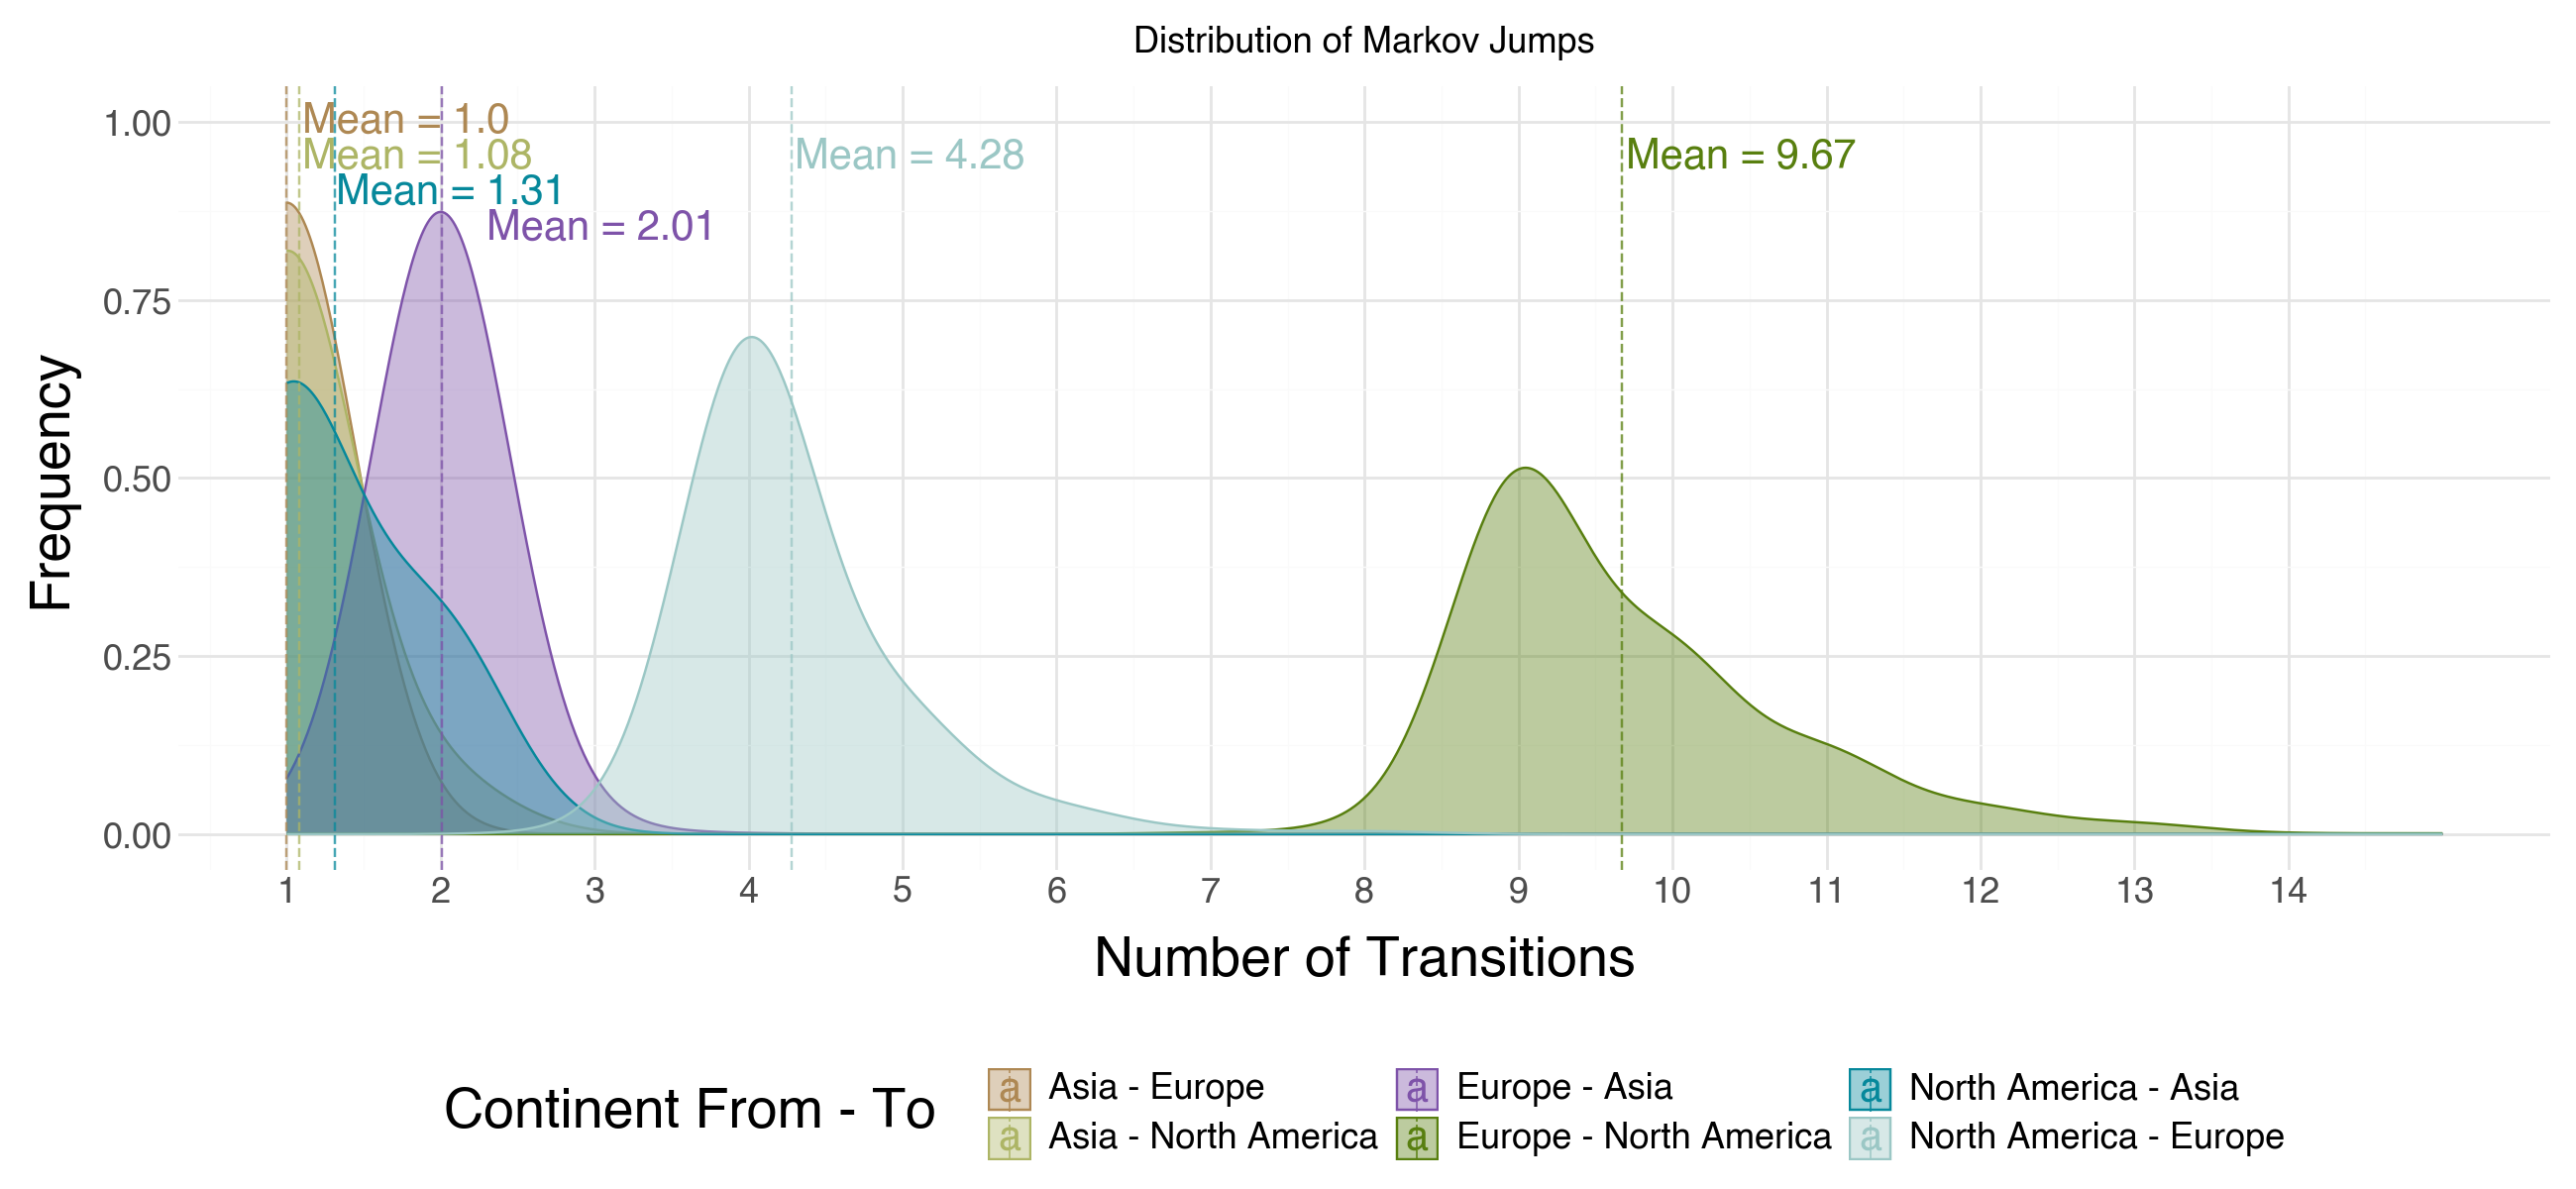

In [200]:
colors = {"Europe - Asia":"#7E53A9",
          "Europe - North America":"#587F0F",
          "North America - Asia":"#06889B",
          "North America - Europe":"#9BC7C5",
          "Asia - Europe":"#AE8853",
          "Asia - North America":"#ADB565"
         }


plt1 = (
    ggplot()
    + geom_density(transition_dense, aes(x = "no_transitions", color = "labels", fill = "labels"), alpha=0.4, bw = 0.45) # default bandwidth (bw) looks to be about 0.15-0.2
    + geom_text(transition_dense_means, aes(x="x-position", y="y-position", label="label", color = "colors"),size=15, ha='left', fontweight = "bold")
    + geom_vline(transition_dense_means, aes(xintercept = "mean_transitions", color = "colors"), linetype = "dashed", size = 0.5, alpha = 0.75)
    + labs(title='Distribution of Markov Jumps',x='Number of Transitions',y='Frequency', color='Continent From - To', fill='Continent From - To')
    # + facet_wrap("labels")
    + scale_fill_manual(colors)
    + scale_color_manual(colors)
    # + xlim(0,15)
    + scale_x_continuous(breaks = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14])
    + theme_minimal()
    + theme(figure_size = (13, 6), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), text=element_text(size=13),
           legend_title=element_text(size=20), legend_direction="horizontal", legend_position="bottom")
    + guides(color=guide_legend(nrow=2), fill=guide_legend(nrow=2))
)

plt1.show()

In [201]:
# plt1.save("./SERAPHIM/output_plots/mj_region_across_posterior.png", format = "png", dpi = 750)
plt1.save("./SERAPHIM/plots/m-jumps_across-posterior_continents.png", format = "png", dpi = 750)

/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 13 x 6 in image.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./SERAPHIM/plots/m-jumps_across-posterior_continents.png


In [52]:
# To plot the number of trans-atlantic and within North America Markov Jumps 

trans_cis_rows = []

for (combo, tree), df in treejumps.groupby(["combo","treeNumber"]):
    trans_cis_rows.append({"tree":tree, "combo": combo, "no_transitions":len(df)})

trans_cis_dense = pd.DataFrame(trans_cis_rows)

trans_cis_dict = {"europe,east-canada":"Trans-Atlantic",
                  "east-canada,northeast-us":"Along Atlantic Coast",
                  "east-canada,europe":"Trans-Atlantic",
                  "north-canada,northwest-us":"Across North America",
                  "northeast-us,north-canada":"Across North America",
                  "east-canada,north-canada":"Across North America",
                  "northeast-us,east-canada":"Along Atlantic Coast",
                  "northeast-us,northwest-us":"Across North America",
                  "northeast-us,europe":"Trans-Atlantic",
                  "europe,northwest-us":"Trans-Atlantic",
                  "europe,north-canada":"Trans-Atlantic",
                  "northwest-us,north-canada":"Across North America",
                  "north-canada,northeast-us":"Across North America",
                  "europe,northeast-us":"Trans-Atlantic",
                  "north-canada,east-canada":"Across North America",
                  "east-canada,northwest-us":"Across North America",
                  "north-canada,europe":"Trans-Atlantic",
                  "northwest-us,east-canada":"Across North America"
                 }

trans_cis_dense["trans-cis"] = trans_cis_dense["combo"].map(trans_cis_dict).fillna("Other")

# trans_cis_dense_filtered = trans_cis_dense[trans_cis_dense["no_transitions"] > 10] # I have ~800 trees, so maybe I want to do transitions that occur >100 times?

In [53]:
trans_cis_dense_means = trans_cis_dense.groupby("trans-cis")["no_transitions"].mean()
trans_cis_dense_means = pd.DataFrame(trans_cis_dense_means).reset_index().rename({"no_transitions":"mean_transitions"}, axis = 1)
trans_cis_dense_means["x"] = trans_cis_dense_means["mean_transitions"] + 0.5
trans_cis_dense_means["label"] = "Mean = " + trans_cis_dense_means["mean_transitions"].round(2).astype(str)

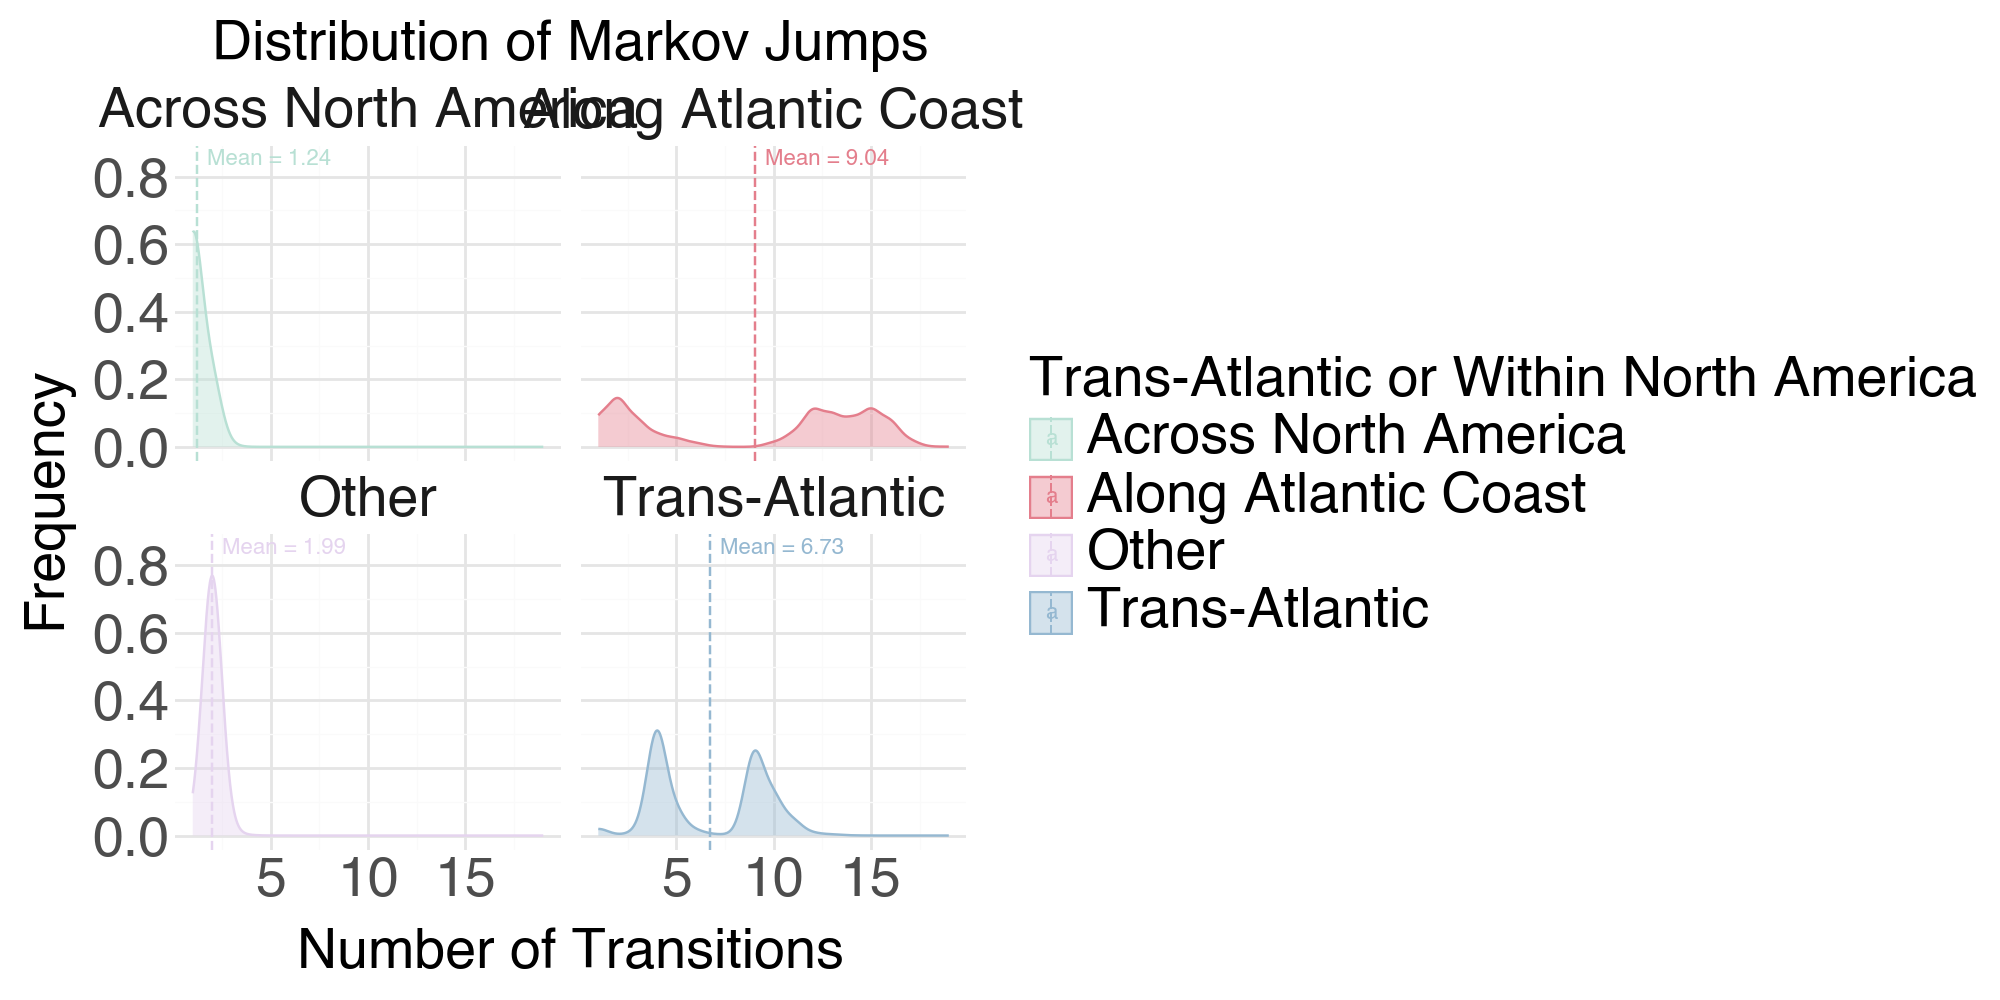

In [54]:
colors2 = {"Trans-Atlantic":"#95b8d1",
          "Across North America":"#b8e0d4",
          "Along Atlantic Coast":"#e47e8c",
          "Other":"#e5d4ef"
          }

plt2 = (
    ggplot()
    + geom_density(trans_cis_dense, aes(x = "no_transitions", color = "trans-cis", fill = "trans-cis"), alpha=0.4, bw = 0.5) # default bandwidth (bw) looks to be about 0.15-0.2
    + geom_text(trans_cis_dense_means, aes(x = "x", y = 0.85, label = "label", color = "trans-cis"), size=8, ha='left')
    + geom_vline(trans_cis_dense_means, aes(xintercept = "mean_transitions", color = "trans-cis"), linetype = "dashed", size = 0.5)
    + labs(title='Distribution of Markov Jumps',x='Number of Transitions',y='Frequency', color='Trans-Atlantic or Within North America', fill='Trans-Atlantic or Within North America')
    + facet_wrap("trans-cis")
    + scale_fill_manual(colors2)
    + scale_color_manual(colors2)
    + theme_minimal()
    + theme(figure_size = (10, 5), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), text=element_text(size=20))
)

plt2.show()

In [184]:
plt2.save("./SERAPHIM/output_plots/mj_trans-cis_across_posterior.png", format = "png", dpi = 750)

/Users/claramal/miniconda3/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 5 in image.
/Users/claramal/miniconda3/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./SERAPHIM/output_plots/mj_trans-cis_across_posterior.png


In [20]:
# To plot the cumulative number of Markov Jumps from Europe to North America and back over time

cumul_jumps_rows = []

mask = ["europe,northamerica","northamerica,europe"]

for (combo, tree), df in treejumps.groupby(["comboContinent","treeNumber"]):
    if combo in mask:
        df["month_bin"] = np.floor(df["date"] * 12) / 12
        df = df.sort_values("month_bin")
        df["cumcount"] = range(1, len(df) + 1) # According to ChatGPT, this line creates a sequence, starting from 1, that counts incidence over time
        columns = ["treeNumber", "date", "month_bin", "comboContinent", "cumcount"]
        cumul_jumps_rows.append(df.loc[:, columns])
    else:
       pass


cumul_jumps = pd.concat(cumul_jumps_rows)

print(cumul_jumps)

    treeNumber         date    month_bin       comboContinent  cumcount
34           1  2022.261208  2022.250000  europe,northamerica         1
18           1  2023.145404  2023.083333  europe,northamerica         2
26           1  2023.106411  2023.083333  europe,northamerica         3
23           1  2023.659795  2023.583333  europe,northamerica         4
2            1  2024.409037  2024.333333  europe,northamerica         5
..         ...          ...          ...                  ...       ...
29         882  2023.714905  2023.666667  northamerica,europe         4
30         883  2022.893284  2022.833333  northamerica,europe         1
26         883  2023.370950  2023.333333  northamerica,europe         2
13         883  2023.640717  2023.583333  northamerica,europe         3
28         883  2023.835012  2023.833333  northamerica,europe         4

[12317 rows x 5 columns]


In [21]:
# It is hard to read the cloud of the posterior 
# So I took the mean cumulative count per transition per month

medians = cumul_jumps.groupby(["month_bin", "comboContinent"])["cumcount"].median().reset_index()

/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path: Removed 15 rows containing missing values.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path: Removed 15 rows containing missing values.


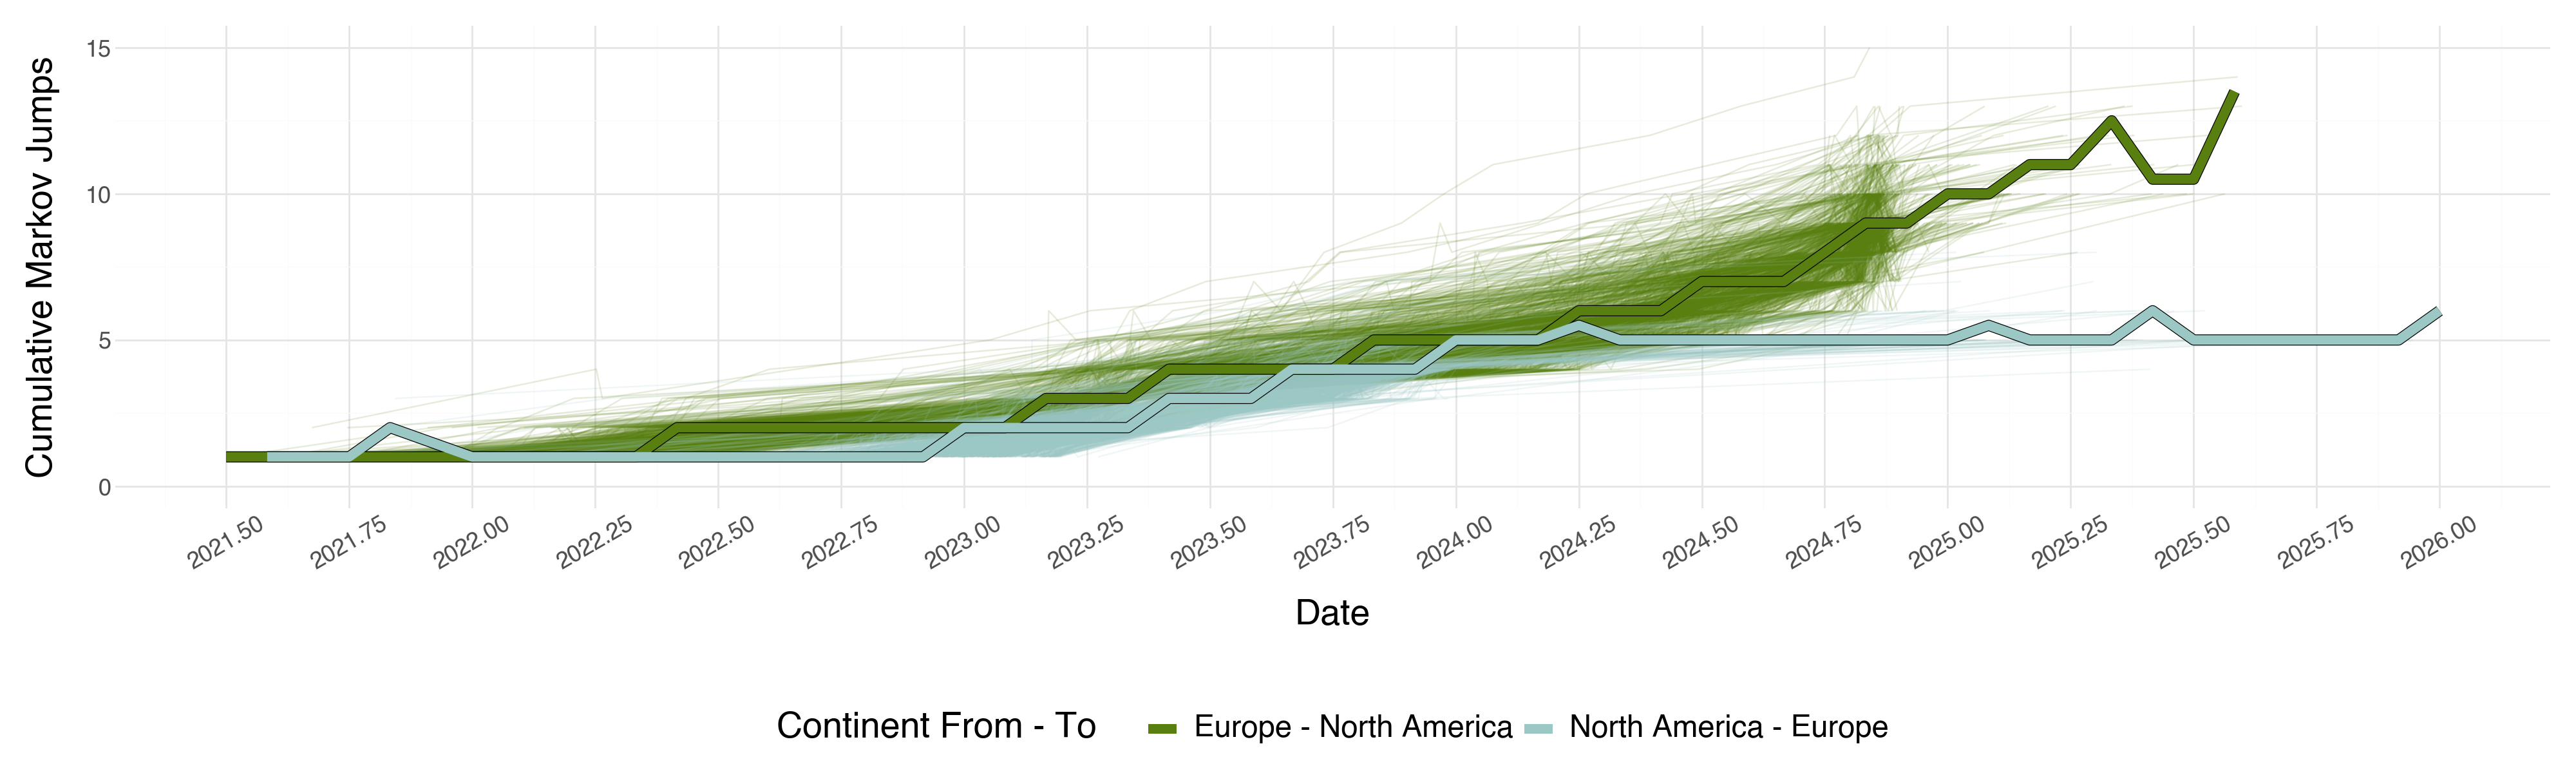

In [22]:
colors3 = {"europe,northamerica":"#587F0F",
          "northamerica,europe":"#9BC7C5"
          }

transition_labels = {"europe,northamerica":"Europe - North America",
        "northamerica,europe":"North America - Europe"
       }

plt3 = (
    ggplot()
    + geom_line(cumul_jumps[cumul_jumps["comboContinent"] == "europe,northamerica"], aes(x = "date", y = "cumcount", group = "treeNumber", color = "comboContinent"), alpha = 0.15)
    + geom_line(cumul_jumps[cumul_jumps["comboContinent"] == "northamerica,europe"], aes(x = "date", y = "cumcount", group = "treeNumber", color = "comboContinent"), alpha = 0.15)
    + geom_line(medians, aes(x = "month_bin", y = "cumcount", group = "comboContinent"), size = 3.5, color = "black")
    + geom_line(medians, aes(x = "month_bin", y = "cumcount", color = "comboContinent"), size = 3) # Mean cumulative count of transitions per month 
    + scale_color_manual(values = colors3, labels = transition_labels)
    + ylim(0, 15)
    + scale_x_continuous(breaks = [2021.5, 2021.75, 2022.0, 2022.25, 2022.5, 2022.75, 2023.0, 2023.25, 2023.5, 2023.75, 2024.0, 2024.25, 2024.5, 2024.75, 
                                   2025.0, 2025.25, 2025.5, 2025.75, 2026],
                        limits = [2021.5, 2026.00])
    + labs(x = "Date", y = "Cumulative Markov Jumps", color = "Continent From - To") 
    + theme_minimal()
    + theme(figure_size = (20, 6), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), axis_text_x = element_text(size = 13, rotation = 30),
            axis_text_y = element_text(size = 13), legend_title = element_text(size = 20), legend_text = element_text(size = 17), legend_direction="horizontal", legend_position="bottom")
)

plt3.show()

In [206]:
# plt3.save("./SERAPHIM/output_plots/cumul_mj_across_posterior.png", format = "png", dpi = 750)
plt3.save("./SERAPHIM/plots/m-jumps_cumul-over-time.png", format = "png", dpi = 750)

/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 20 x 6 in image.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./SERAPHIM/plots/m-jumps_cumul-over-time.png
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path: Removed 15 rows containing missing values.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path: Removed 15 rows containing missing values.


In [11]:
def get_monthyear(y):
    if 2020.0000000 <= y < 2020.0846995:
        return "january"
    elif 2020.0846995 <= y < 2020.1639344:
        return "february"
    elif 2020.1639344 <= y < 2020.2486339:
        return "march"
    elif 2020.2486339 <= y < 2020.3306011:
        return "april"
    elif 2020.3306011 <= y < 2020.4153005:
        return "may"
    elif 2020.4153005 <= y < 2020.4972678:
        return "june"
    elif 2020.4972678 <= y < 2020.5819672:
        return "july"
    elif 2020.5819672 <= y < 2020.6666667:
        return "august"
    elif 2020.6666667 <= y < 2020.7486339:
        return "september"
    elif 2020.7486339 <= y < 2020.8333333:
        return "october"
    elif 2020.8333333 <= y < 2020.9153005:
        return "november"
    elif 2020.9153005 <= y < 2021.0:
        return "december"
    elif 2021.0 <= y < 2021.0849315:
        return "january"
    elif 2021.0849315 <= y < 2021.1616438:
        return "february"
    elif 2021.1616438 <= y < 2021.2465753:
        return "march"
    elif 2021.2465753 <= y < 2021.328767:
        return "april"
    elif 2021.328767 <= y < 2021.4136986:
        return "may"
    elif 2021.4136986 <= y < 2021.4958904:
        return "june"
    elif 2021.4958904 <= y < 2021.5808219:
        return "july"
    elif 2021.5808219 <= y < 2021.665753:
        return "august"
    elif 2021.665753 <= y < 2021.747945: 
        return "september"
    elif 2021.747945 <= y < 2021.832877: 
        return "october"
    elif 2021.832877 <= y < 2021.915068: 
        return "november"
    elif 2021.915068 <= y < 2022.000000: 
        return "december"
    elif 2022.000000 <= y < 2022.084932: 
        return "january"
    elif 2022.084932 <= y < 2022.161644:
        return "february"
    elif 2022.161644 <= y < 2022.246575:
        return "march"
    elif 2022.246575 <= y < 2022.328767:
        return "april"
    elif 2022.328767 <= y < 2022.413699:
        return "may"
    elif 2022.413699 <= y < 2022.495890:
        return "june"
    elif 2022.495890 <= y < 2022.580822:
        return "july"
    elif 2022.580822 <= y < 2022.665753:
        return "august"
    elif 2022.665753 <= y < 2022.747945:
        return "september"
    elif 2022.747945 <= y < 2022.832877: 
        return "october"
    elif 2022.832877 <= y < 2022.915068:
        return "november"
    elif 2022.915068 <= y < 2023.000000:
        return "december"
    elif 2023.000000 <= y < 2023.084932:
        return "january"
    elif 2023.084932 <= y < 2023.161644:
        return "february"
    elif 2023.161644 <= y < 2023.246575:
        return "march"
    elif 2023.246575 <= y < 2023.328767:
        return "april"
    elif 2023.328767 <= y < 2023.413699:
        return "may"
    elif 2023.413699 <= y < 2023.495890:
        return "june"
    elif 2023.495890 <= y < 2023.580822:
        return "july"
    elif 2023.580822 <= y < 2023.665753:
        return "august"
    elif 2023.665753 <= y < 2023.747945:
        return "september"
    elif 2023.747945 <= y < 2023.832877:
        return "october"
    elif 2023.832877 <= y < 2023.915068:
        return "november"
    elif 2023.915068 <= y < 2024.000000:
        return "december"
    elif 2024.000000 <= y < 2024.084699:
        return "january"
    elif 2024.084699 <= y < 2024.163934:
        return "february"
    elif 2024.163934 <= y < 2024.248634:
        return "march"
    elif 2024.248634 <= y < 2024.330601:
        return "april"
    elif 2024.330601 <= y < 2024.415301:
        return "may"
    elif 2024.415301 <= y < 2024.497268:
        return "june"
    elif 2024.497268 <= y < 2024.581967:
        return "july"
    elif 2024.581967 <= y < 2024.666667:
        return "august"
    elif 2024.666667 <= y < 2024.748634:
        return "september"
    elif 2024.748634 <= y < 2024.833333:
        return "october"
    elif 2024.833333 <= y < 2024.915301:
        return "november"
    elif 2024.915301 <= y < 2025.00000:
        return "december"
    elif 2025.000000 <= y < 2025.084932:
        return "january"
    elif 2025.084932 <= y < 2025.161644:
        return "february"
    elif 2025.161644 <= y < 2025.246575:
        return "march"
    elif 2025.246575 <= y < 2025.328767:
        return "april"
    elif 2025.328767 <= y < 2025.413699:
        return "may"
    elif 2025.413699 <= y < 2025.495890:
        return "june"
    elif 2025.495890 <= y < 2025.580822:
        return "july"
    elif 2025.580822 <= y < 2025.665753:
        return "august"
    elif 2025.665753 <= y < 2025.747945:
        return "september"
    elif 2025.747945 <= y < 2025.832877:
        return "october"
    elif 2025.832877 <= y < 2025.915068:
        return "november"
    elif 2025.915068 <= y < 2026.00000:
        return "december"
    elif 2026.0 <= y < 2026.0849315:
        return "january"
    else:
        return "pre-2020"

In [12]:
def get_seasonyear(y):
    if y <= 2020.2158470: # most of winter 2020
        return "winter"
    elif 2020.2158469 < y <= 2020.4672131: # spring 2020
        return "spring"
    elif 2020.4672131 < y <= 2020.7240437: # summer 2020
        return "summer"
    elif 2020.7240437 < y <= 2020.969945: # fall 2020
        return "autumn"
    elif 2020.969945 < y <= 2021.2136986: # winter 2020-21
        return "winter"
    elif 2021.2136986 < y <= 2021.4657534: # spring 2021
        return "spring"
    elif 2021.4657534 < y <= 2021.7232877: # summer 2021
        return "summer"
    elif 2021.7232876 < y <= 2021.96986: # autumn 2021
        return "autumn"
    elif 2021.96986 < y <= 2022.21096: # winter 2021-22
        return "winter"
    elif 2022.21096 < y <= 2022.46575: # spring 2022
        return "spring"
    elif 2022.46575 < y <= 2022.72055: # summer 2022
        return "summer"
    elif 2022.72055 < y <= 2022.96712: # autumn 2022
        return "autumn"
    elif 2022.96712 < y <= 2023.21096: # winter 2022-23
        return "winter"
    elif 2023.21096 < y <= 2023.46575: # spring 2023
        return "spring"
    elif 2023.46575 < y <= 2023.72329: # summer 2023
        return "summer"
    elif 2023.72329 < y <= 2023.96712: # autumn 2023
        return "autumn"
    elif 2023.96712 < y <= 2024.21038: # winter 2023-24
        return "winter"
    elif 2024.21038 < y <= 2024.46448: # spring 2024
        return "spring"
    elif 2024.46448 < y <= 2024.72131: # summer 2024
        return "summer"
    elif 2024.72131 < y <= 2024.96721: # autumn 2024
        return "autumn"
    elif 2024.96721 < y <= 2025.213699: # winter 2024-25
        return "winter"
    elif 2025.213699 < y <= 2025.468493: # spring 2025
        return "spring"
    elif 2025.468493 < y <= 2025.723288: # summer 2025
        return "summer"
    elif 2025.723288 < y <= 2025.969863: # autumn 2025
        return "autumn"
    elif 2025.969863 < y <= 2026.213699: # winter 2025-26
        return "winter"
    else:
        return "unknown"

In [13]:
# To plot the probability of Markov jumps occuring in each month

months = ["january", "february", "march", "april", "may", "june", "july", "august", "september", "october", "november", "december"] # "pre-2020"]

# for (combo, tree), df in treejumps.groupby(["comboContinent","treeNumber"]):
#     if combo in mask:
#         df["month"] = df["date"].apply(get_monthyear)
#         df["season"] = df["date"].apply(get_seasonyear)
#         df["total_trans"] = len(df)
#         for month, df2 in df.groupby("month"):
#                 df.loc[df["month"] == month, "trans_per_month"] = len(df2)
#         for season, df2 in df.groupby("season"):
#             df.loc[df["season"] == season, "trans_per_season"] = len(df2)
#         df["prop_per_month"] = df["trans_per_month"] / df["total_trans"]
#         df["prop_per_seas"] = df["trans_per_season"] / df["total_trans"]
#         columns = ["treeNumber", "date", "comboContinent", "month", "season", 
#                    "total_trans", "trans_per_month", "trans_per_season", 
#                    "prop_per_month", "prop_per_seas"]
#         permonth_rows.append(df.loc[:, columns])
#     else:
#        pass


def transitions_per_month(df):
    mask = ["europe,northamerica","northamerica,europe"] 
    df_new = df.loc[df["comboContinent"].isin(mask)] # We only want transitions between North America and Europe

    df_new["month"] = df_new["date"].apply(get_monthyear) # Assign month to each jump
    df_new["season"] = df_new["date"].apply(get_seasonyear) # Assign season to each jump (not currently used, but you never know)

    df_new = df_new[~(df_new["month"] == "pre-2020")] # Remove jumps before 2020 

    permonth_dict = []

    for (combo, tree), groupeddf in df_new.groupby(["comboContinent", "treeNumber"]): # For each transition and each tree
        total_trans = len(groupeddf) # Total number of that transition direction
        # print(groupeddf)

        # for month, monthdf in groupeddf.groupby("month"):
        #     print(month, len(monthdf))
        
        for month in months:  
            if month in set(groupeddf["month"]):
                # print(f"{month} in tree {tree} and {combo}")
                permonth_dict.append({"tree":tree, "combo":combo, "total_trans":total_trans, "month":month, "month_trans":len(groupeddf.loc[groupeddf["month"] == month])})
            else:
            #     # print(f"{month} not in tree {tree} and {combo}")
                permonth_dict.append({"tree":tree, "combo":combo, "total_trans":total_trans, "month":month, "month_trans":0.0})


    # for (combo, tree, month), groupeddf in df_new.groupby(["comboContinent", "treeNumber", "month"]):
    #     print(groupeddf)

    #print(permonth_dict)
    permonth = pd.DataFrame(permonth_dict)

    return(permonth)

permonth = transitions_per_month(treejumps)

permonth["prop_trans"] = permonth["month_trans"] / permonth["total_trans"]
permonth["month_combo"] = permonth["month"] + "_" + permonth["combo"]

In [14]:
# permonth_oct = permonth.loc[(permonth["month"] == "october") & (permonth["combo"] == "northamerica,europe")]

# print(permonth_oct)
# print(permonth_oct["month_trans"].value_counts())

# permonth_NamEu = permonth.loc[permonth["combo"] == "northamerica,europe"]

# hi_plot = (
#     ggplot(permonth_NamEu, aes(x = "month_trans"))
#     + geom_histogram()
#     + facet_wrap("month")
#     + labs(x = "Date", y = "Frequency of \n Transitions Over Time")
#     + theme_minimal()
#     + theme(figure_size = (20, 5), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), axis_text_y = element_text(size = 13),
#             axis_text_x = element_text(size = 13), legend_direction="horizontal", legend_position="bottom")
# )

# hi_plot.show()

In [15]:
permonth_hpds = permonth.groupby(["month", "combo"])["month_trans"].apply(lambda col: az.hdi(col.values, hdi_prob=0.95)).apply(pd.Series).reset_index()
permonth_median = permonth.groupby(["month", "combo"])["month_trans"].median().reset_index(name = "median")
permonth_mean = permonth.groupby(["month", "combo"])["month_trans"].mean().reset_index(name = "mean")
permonth_quant = permonth_hpds.merge(permonth_median, on = ["month", "combo"])
permonth_quant = permonth_quant.rename({0:"lower", 1:"upper"}, axis = 1)

In [17]:
mask = ["europe,northamerica","northamerica,europe"]
trans_overtime = treejumps.loc[treejumps["comboContinent"].isin(mask)]

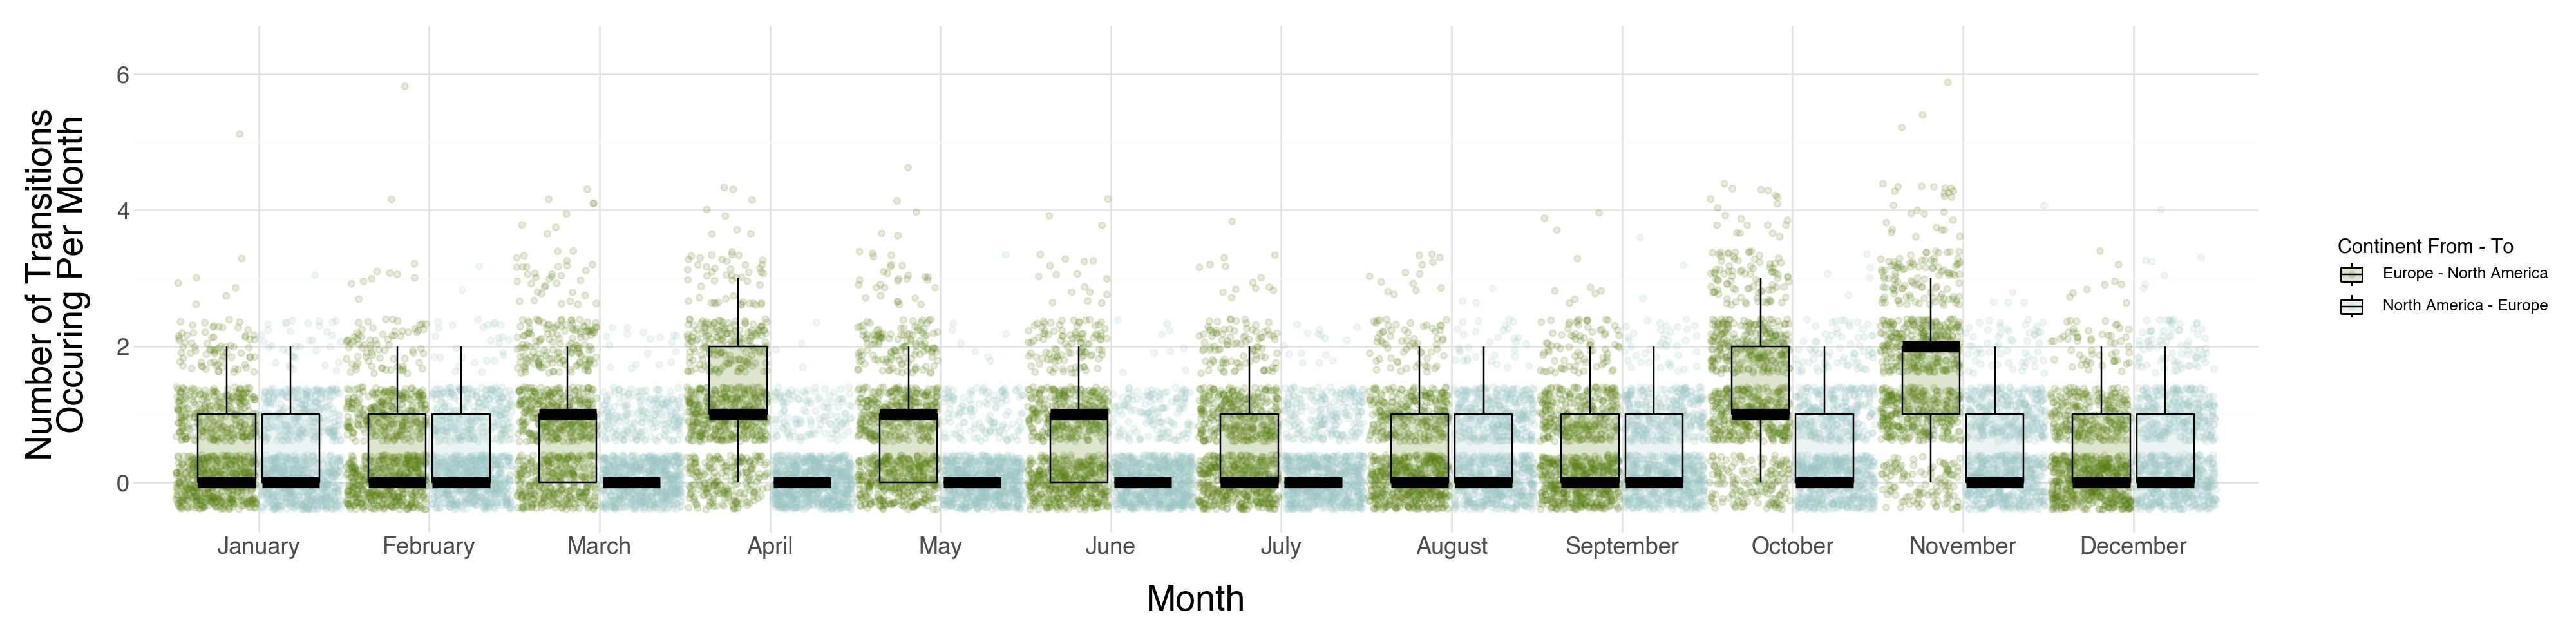

/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_density : Removed 18 rows containing non-finite values.


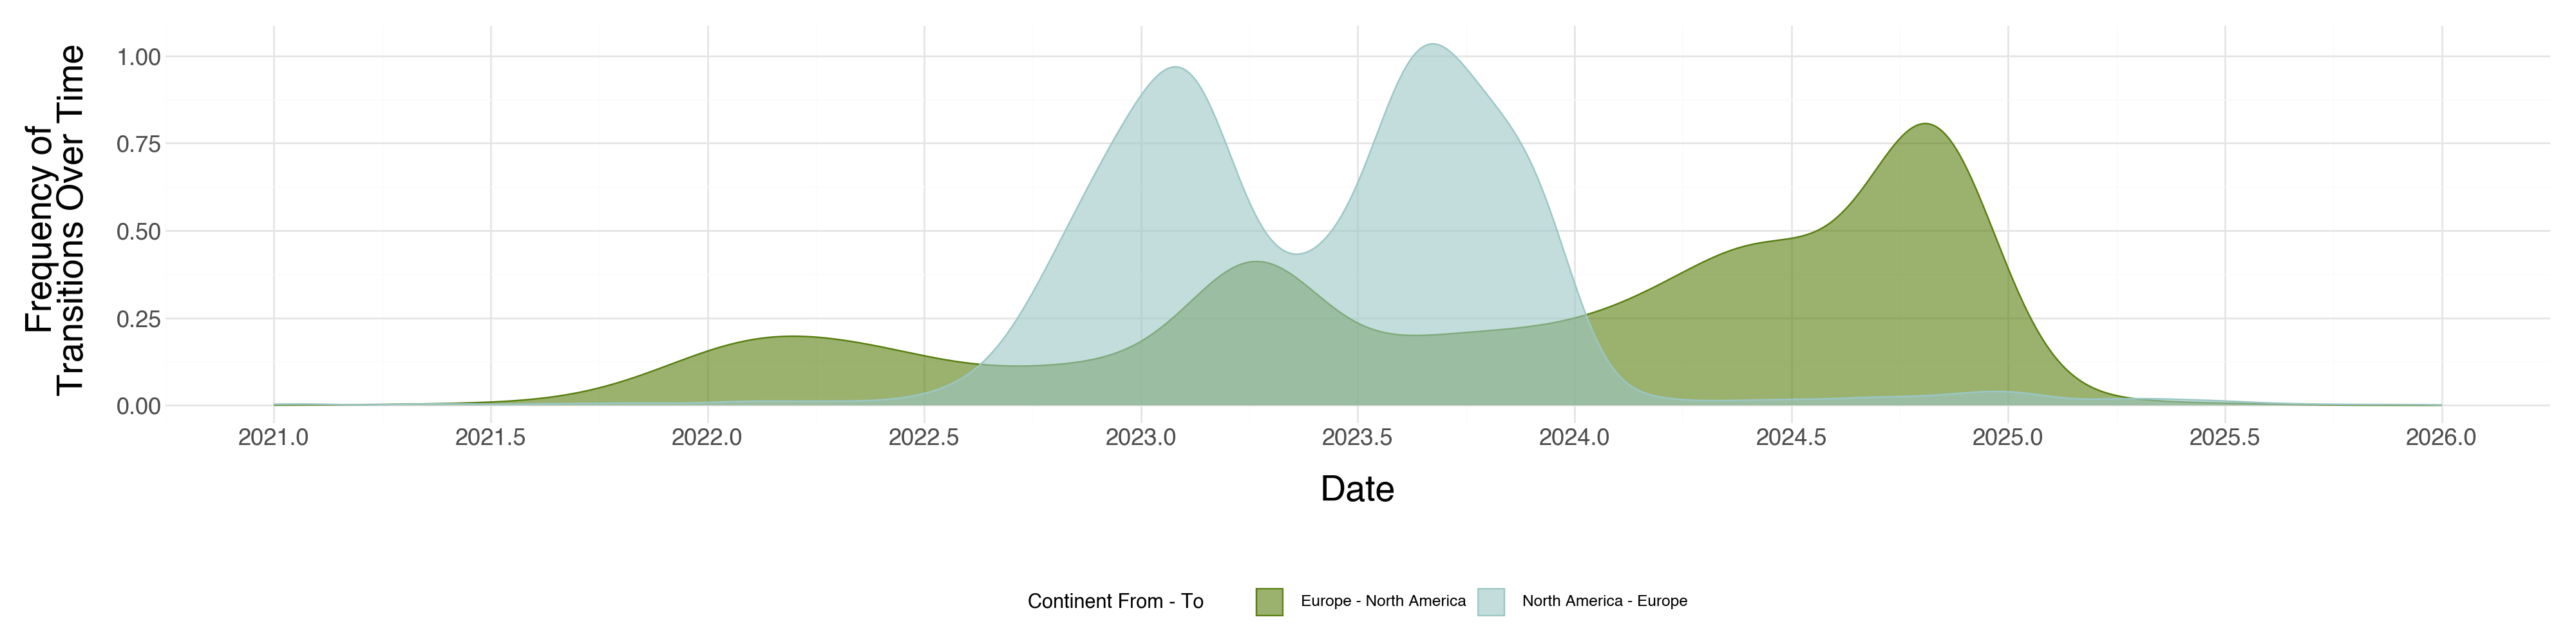

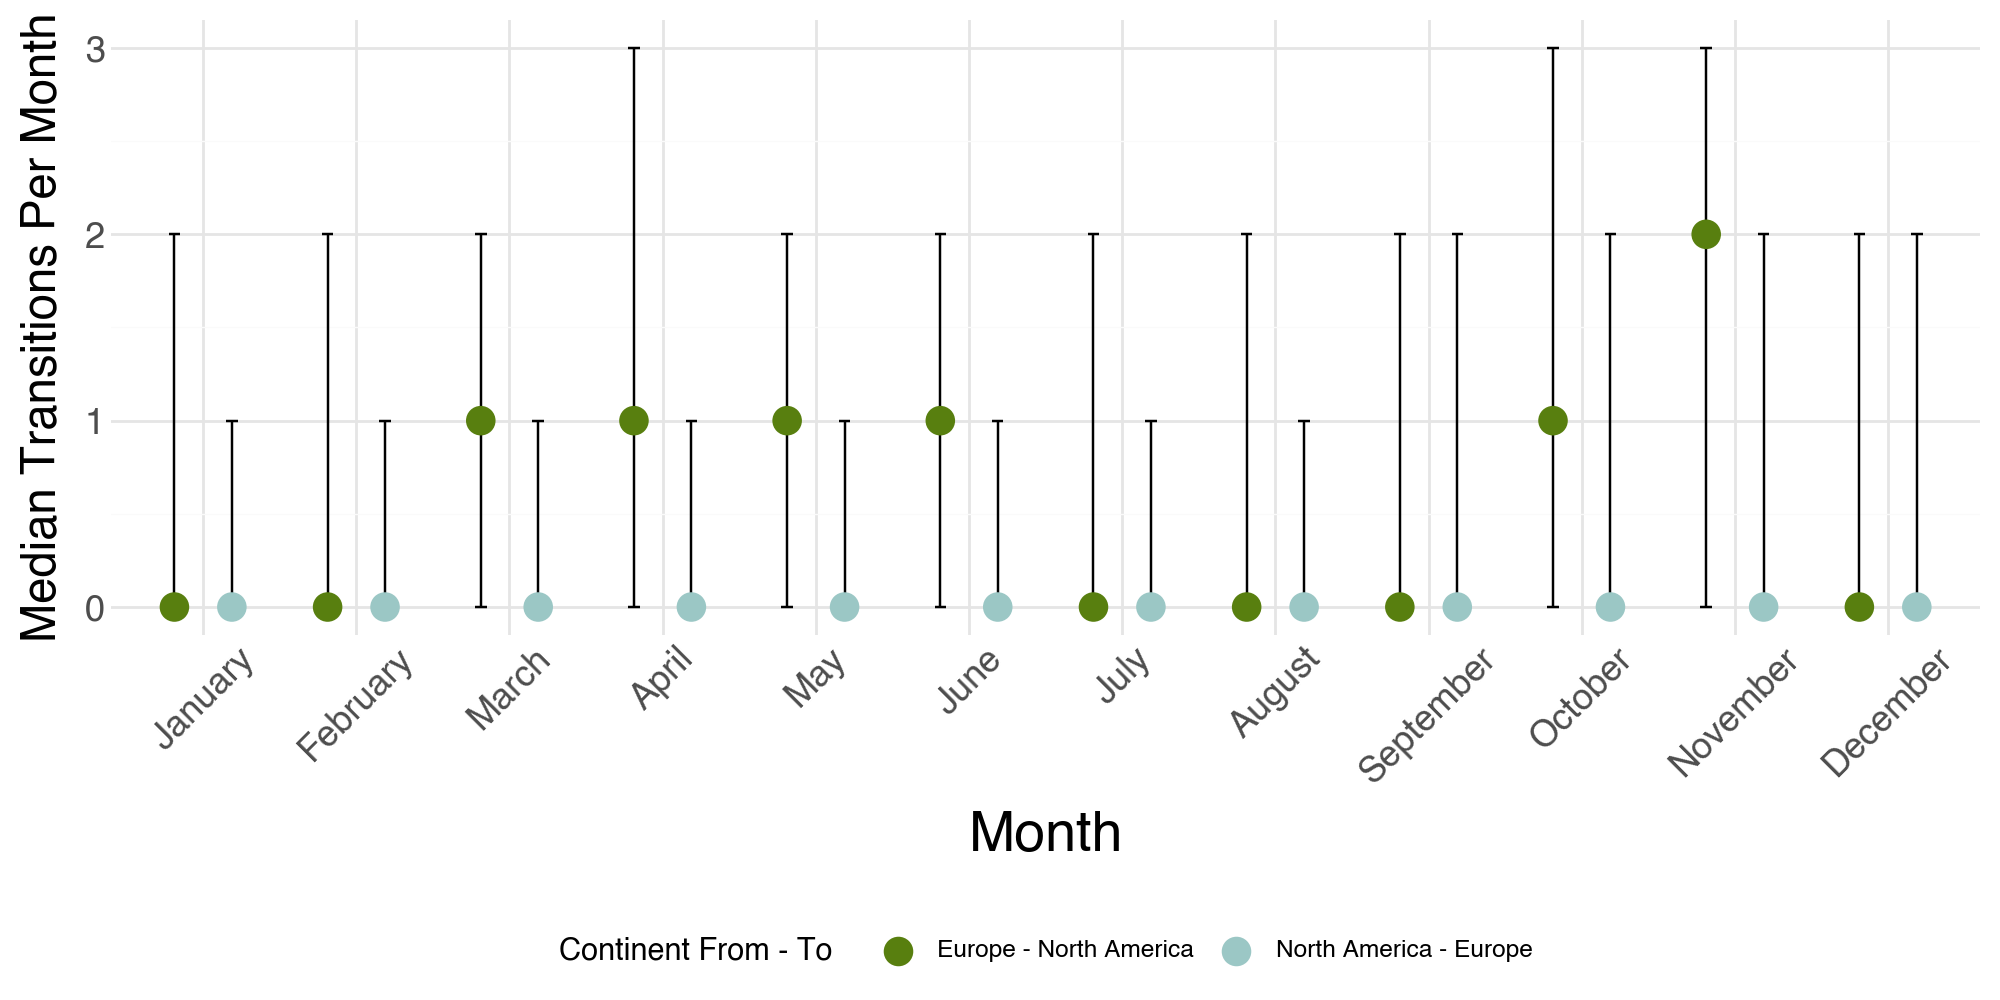

In [23]:
permonth["month"] = pd.Categorical(permonth["month"], categories=months, ordered=True)
permonth_quant["month"] = pd.Categorical(permonth_quant["month"], categories=months, ordered=True)

# plt4 = (
#     ggplot(permonth, aes(x = "season", y = "prop_per_seas", fill = "comboContinent", color = "comboContinent"))
#     + geom_violin()
#     # + geom_point(position = "jitter")
#     # + geom_col(position = "dodge")
#     # + labs(x = "Month", y = "Proportion of Transitions Occuring Per Month", fill = "Continent From - To", color = "Continent From - To")
#     + labs(x = "Season", y = "Proportion of Transitions \n Occuring Per Season", fill = "Continent From - To", color = "Continent From - To")
#     + scale_fill_manual(values = colors3, labels = transition_labels)
#     + scale_color_manual(values = colors3, labels = transition_labels)
#     + theme_minimal()
#     + theme(figure_size = (10, 5), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), text=element_text(size=20))
# )

plt4_alt1 = (
    ggplot(permonth, aes(x = "month", y = "month_trans", color = "combo", fill = "combo"))
    # + geom_jitter(aes(fill = "combo", color = "combo"), alpha = 0.15, position=position_jitterdodge(dodge_width=1, jitter_width=0.47,jitter_height=0.4))
    + geom_jitter(alpha = 0.15, position=position_jitterdodge(dodge_width=1, jitter_width=0.47,jitter_height=0.4))
    # + geom_boxplot(aes(group = "month_combo"), color = "black", position = "dodge", alpha = 0.2, fatten = 7, outlier_alpha = 0)
    + geom_boxplot(stat = "boxplot", color = "black", position = "dodge2", alpha = 0.2, fatten = 7, outlier_alpha = 0)
    + labs(x = "Month", y = "Number of Transitions \n Occuring Per Month", fill = "Continent From - To", color = "Continent From - To")
    + scale_fill_manual(values = colors3, labels = transition_labels)
    + scale_color_manual(values = colors3, labels = transition_labels)
    + scale_x_discrete(labels=["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"])
    + theme_minimal()
    + theme(figure_size = (20, 5), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), axis_text_y = element_text(size = 13), axis_text_x = element_text(size = 13))
)

plt4_alt2 = (
    ggplot(trans_overtime, aes(x = "date", fill = "comboContinent", color = "comboContinent"))
    + geom_density(alpha = 0.6)
    + labs(x = "Date", y = "Frequency of \n Transitions Over Time", fill = "Continent From - To", color = "Continent From - To")
    + scale_fill_manual(values = colors3, labels = transition_labels)
    + scale_color_manual(values = colors3, labels = transition_labels)
    + scale_x_continuous(
        breaks = [2021, 2021.5, 2022.0, 2022.5, 2023.0, 2023.5, 2024.0, 2024.5, 2025.0, 2025.5, 2026],
        # breaks = [2020, 2020.25, 2020.5, 2020.75, 2021, 2021.25, 2021.5, 2021.75, 2022.0, 2022.25, 2022.5, 2022.75, 2023.0, 2023.25, 2023.5, 2023.75, 2024.0, 2024.25, 2024.5, 2024.75, 2025.0, 2025.25, 2025.5, 2025.75, 2026],
        limits = [2021, 2026],
        # limits = [2022.35, 2024.25]
    )
    + theme_minimal()
    + theme(figure_size = (20, 5), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), axis_text_y = element_text(size = 13),
            axis_text_x = element_text(size = 13), legend_direction="horizontal", legend_position="bottom")
)

# plt4_alt3 = (
#     ggplot(permonth, aes(x = "trans_per_month", fill = "comboContinent", color = "comboContinent"))
#     + geom_histogram(position = "dodge", binwidth = 1)
#     + facet_wrap("month")
#     + labs(x = "Number of Transitions \n Over Time", y = "Frequency", fill = "Continent From - To", color = "Continent From - To")
#     + scale_fill_manual(values = colors3, labels = transition_labels)
#     + scale_color_manual(values = colors3, labels = transition_labels)
#     + theme_minimal()
#     + xlim(-1, 6)
#     + scale_x_continuous(breaks=np.arange(-1, 7, 1))
#     + theme(figure_size = (10, 10), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), text=element_text(size=20),
#            legend_direction="horizontal", legend_position="bottom")
# )

plt4_alt4 = (
    ggplot(permonth_quant, aes(x = "month", y = "median", color = "combo"))
    + geom_errorbar(aes(ymin = "lower", ymax = "upper", group = "combo"), width = 0.15, color = "black", position=position_dodge(width=0.75))
    + geom_point(stat = "identity", size = 5, position=position_dodge(width=0.75))
    + labs(x = "Month", y = "Median Transitions Per Month", fill = "Continent From - To", color = "Continent From - To")
    + scale_fill_manual(values = colors3, labels = transition_labels)
    + scale_color_manual(values = colors3, labels = transition_labels)
    + scale_x_discrete(labels=["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"])
    + theme_minimal()
    + theme(figure_size = (10, 5), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 17), axis_text_y = element_text(size = 13),
            axis_text_x = element_text(rotation = 45, size = 13), legend_direction="horizontal", legend_position="bottom")
)

# plt4.show()
plt4_alt1.show()
plt4_alt2.show()
# plt4_alt3.show()
plt4_alt4.show()

In [366]:
# plt4.save("./SERAPHIM/output_plots/mj_permonth_across_posterior.png", format = "png", dpi = 750)
plt4_alt1.save("./SERAPHIM/plots/m-jumps_per-month_boxplot.png", format = "png", dpi = 750)
plt4_alt2.save("./SERAPHIM/plots/m-jumps_freq-over-time.png", format = "png", dpi = 750)
# plt4_alt3.save("./SERAPHIM/output_plots/mj_perseason_across_posterior_v3.png", format = "png", dpi = 750)
plt4_alt4.save("./SERAPHIM/plots/m-jumps_per-month.png", format = "png", dpi = 750)

/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 20 x 5 in image.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./SERAPHIM/plots/m-jumps_per-month_boxplot.png
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 20 x 5 in image.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./SERAPHIM/plots/m-jumps_freq-over-time.png
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_density : Removed 18 rows containing non-finite values.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 5 in image.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-pa

In [25]:
# Kruskal Wallis test for the statistical significance of the number of transitions per month

# start with the dataset of transitions per month across the entire distribution
# print(permonth)
permonth_EuNAm = permonth[permonth["combo"] == "europe,northamerica"]
permonth_NAmEu = permonth[permonth["combo"] == "northamerica,europe"]

# I want to compare the months within each combo
def kruskal_test(df, months):

    count_dict = {}

    for month in months:
        month_count = df["month_trans"].loc[df["month"] == month].astype(int)
        # print(month, len(month_count))
        count_dict[month] = month_count

    # for month, values in count_dict.items():
    #     print(month, len(values), values.tolist())

    print("Number of groups", len(count_dict))

    result = stats.kruskal(*count_dict.values())

    return(result)

# EuNAm_kruskal = kruskal_test(permonth_EuNAm, months)
# NAmEu_kruskal = kruskal_test(permonth_NAmEu, months)

jan_EuNAm = permonth_EuNAm["month_trans"].loc[permonth_EuNAm["month"] == "january"]
feb_EuNAm = permonth_EuNAm["month_trans"].loc[permonth_EuNAm["month"] == "february"]
mar_EuNAm = permonth_EuNAm["month_trans"].loc[permonth_EuNAm["month"] == "march"]
apr_EuNAm = permonth_EuNAm["month_trans"].loc[permonth_EuNAm["month"] == "april"]
may_EuNAm = permonth_EuNAm["month_trans"].loc[permonth_EuNAm["month"] == "may"]
jun_EuNAm = permonth_EuNAm["month_trans"].loc[permonth_EuNAm["month"] == "june"]
jul_EuNAm = permonth_EuNAm["month_trans"].loc[permonth_EuNAm["month"] == "july"]
aug_EuNAm = permonth_EuNAm["month_trans"].loc[permonth_EuNAm["month"] == "august"]
sep_EuNAm = permonth_EuNAm["month_trans"].loc[permonth_EuNAm["month"] == "september"]
oct_EuNAm = permonth_EuNAm["month_trans"].loc[permonth_EuNAm["month"] == "october"]
nov_EuNAm = permonth_EuNAm["month_trans"].loc[permonth_EuNAm["month"] == "november"]
dec_EuNAm = permonth_EuNAm["month_trans"].loc[permonth_EuNAm["month"] == "december"]

EuNAm_kruskal = stats.kruskal(jan_EuNAm, feb_EuNAm, mar_EuNAm, apr_EuNAm, may_EuNAm, jun_EuNAm,
                              jul_EuNAm, aug_EuNAm, sep_EuNAm, oct_EuNAm, nov_EuNAm, dec_EuNAm)

print(EuNAm_kruskal)


jan_NAmEu = permonth_NAmEu["month_trans"].loc[permonth_NAmEu["month"] == "january"]
feb_NAmEu = permonth_NAmEu["month_trans"].loc[permonth_NAmEu["month"] == "february"]
mar_NAmEu = permonth_NAmEu["month_trans"].loc[permonth_NAmEu["month"] == "march"]
apr_NAmEu = permonth_NAmEu["month_trans"].loc[permonth_NAmEu["month"] == "april"]
may_NAmEu = permonth_NAmEu["month_trans"].loc[permonth_NAmEu["month"] == "may"]
jun_NAmEu = permonth_NAmEu["month_trans"].loc[permonth_NAmEu["month"] == "june"]
jul_NAmEu = permonth_NAmEu["month_trans"].loc[permonth_NAmEu["month"] == "july"]
aug_NAmEu = permonth_NAmEu["month_trans"].loc[permonth_NAmEu["month"] == "august"]
sep_NAmEu = permonth_NAmEu["month_trans"].loc[permonth_NAmEu["month"] == "september"]
oct_NAmEu = permonth_NAmEu["month_trans"].loc[permonth_NAmEu["month"] == "october"]
nov_NAmEu = permonth_NAmEu["month_trans"].loc[permonth_NAmEu["month"] == "november"]
dec_NAmEu = permonth_NAmEu["month_trans"].loc[permonth_NAmEu["month"] == "december"]

NAmEu_kruskal = stats.kruskal(jan_NAmEu, feb_NAmEu, mar_NAmEu, apr_NAmEu, may_NAmEu, jun_NAmEu,
                              jul_NAmEu, aug_NAmEu, sep_NAmEu, oct_NAmEu, nov_NAmEu, dec_NAmEu)

print(NAmEu_kruskal)

# stats.kruskal()

KruskalResult(statistic=np.float64(1607.7198178551002), pvalue=np.float64(0.0))
KruskalResult(statistic=np.float64(636.4668954519893), pvalue=np.float64(2.2010728203560313e-129))


                 Generalized Linear Model Regression Results                  
Dep. Variable:            month_trans   No. Observations:                10596
Model:                            GLM   Df Residuals:                    10584
Model Family:                 Poisson   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -11711.
Date:                Wed, 19 Aug 2026   Deviance:                       10134.
Time:                        12:01:44   Pearson chi2:                 9.10e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1310
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -0.65

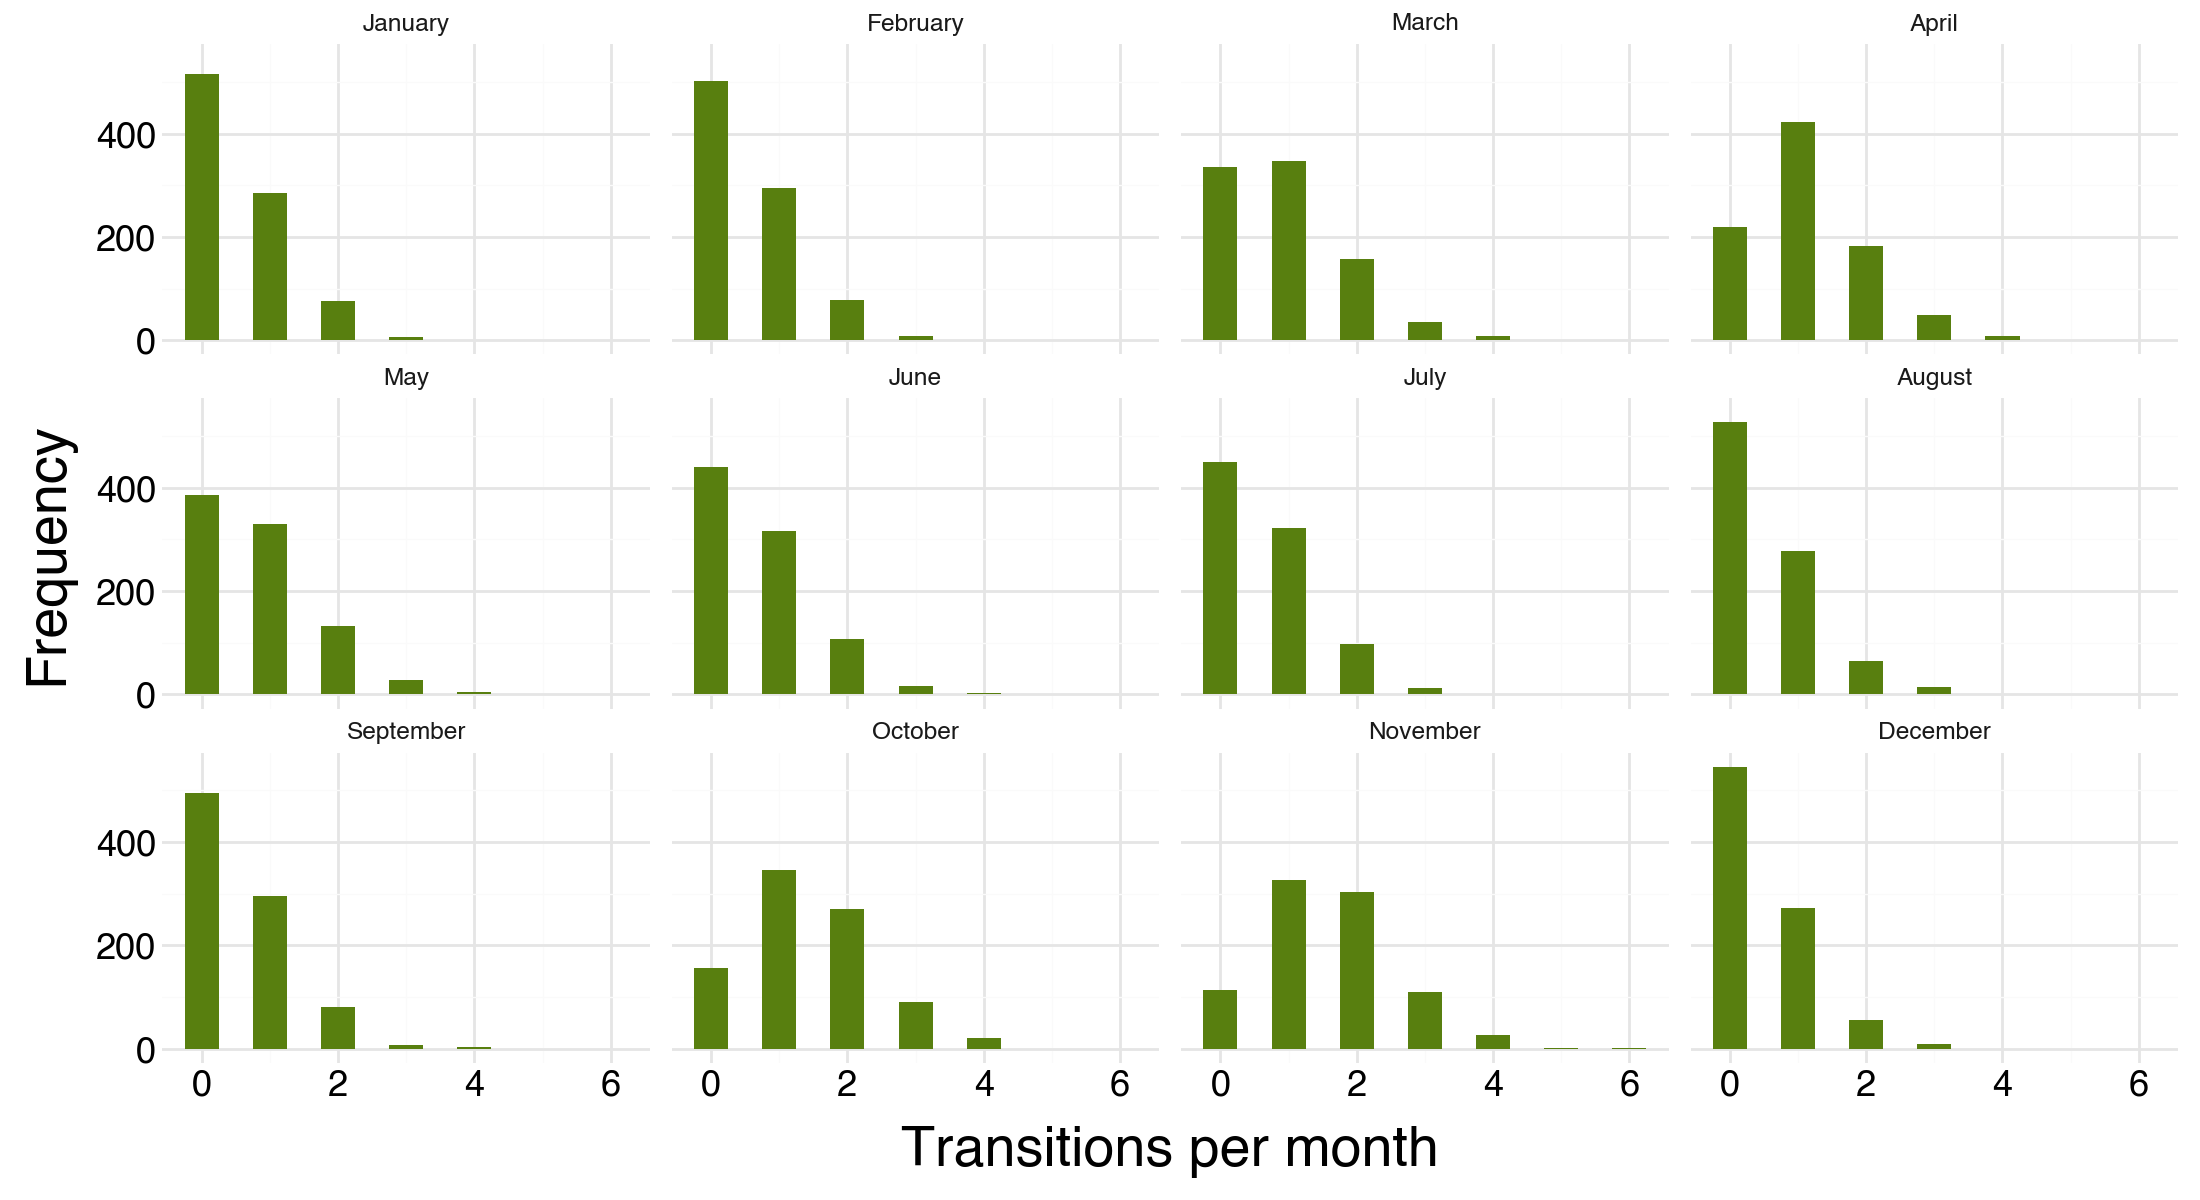

                 Generalized Linear Model Regression Results                  
Dep. Variable:            month_trans   No. Observations:                10596
Model:                            GLM   Df Residuals:                    10584
Model Family:                 Poisson   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7687.0
Date:                Wed, 19 Aug 2026   Deviance:                       8454.0
Time:                        12:01:44   Pearson chi2:                 9.14e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.05728
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -0.91

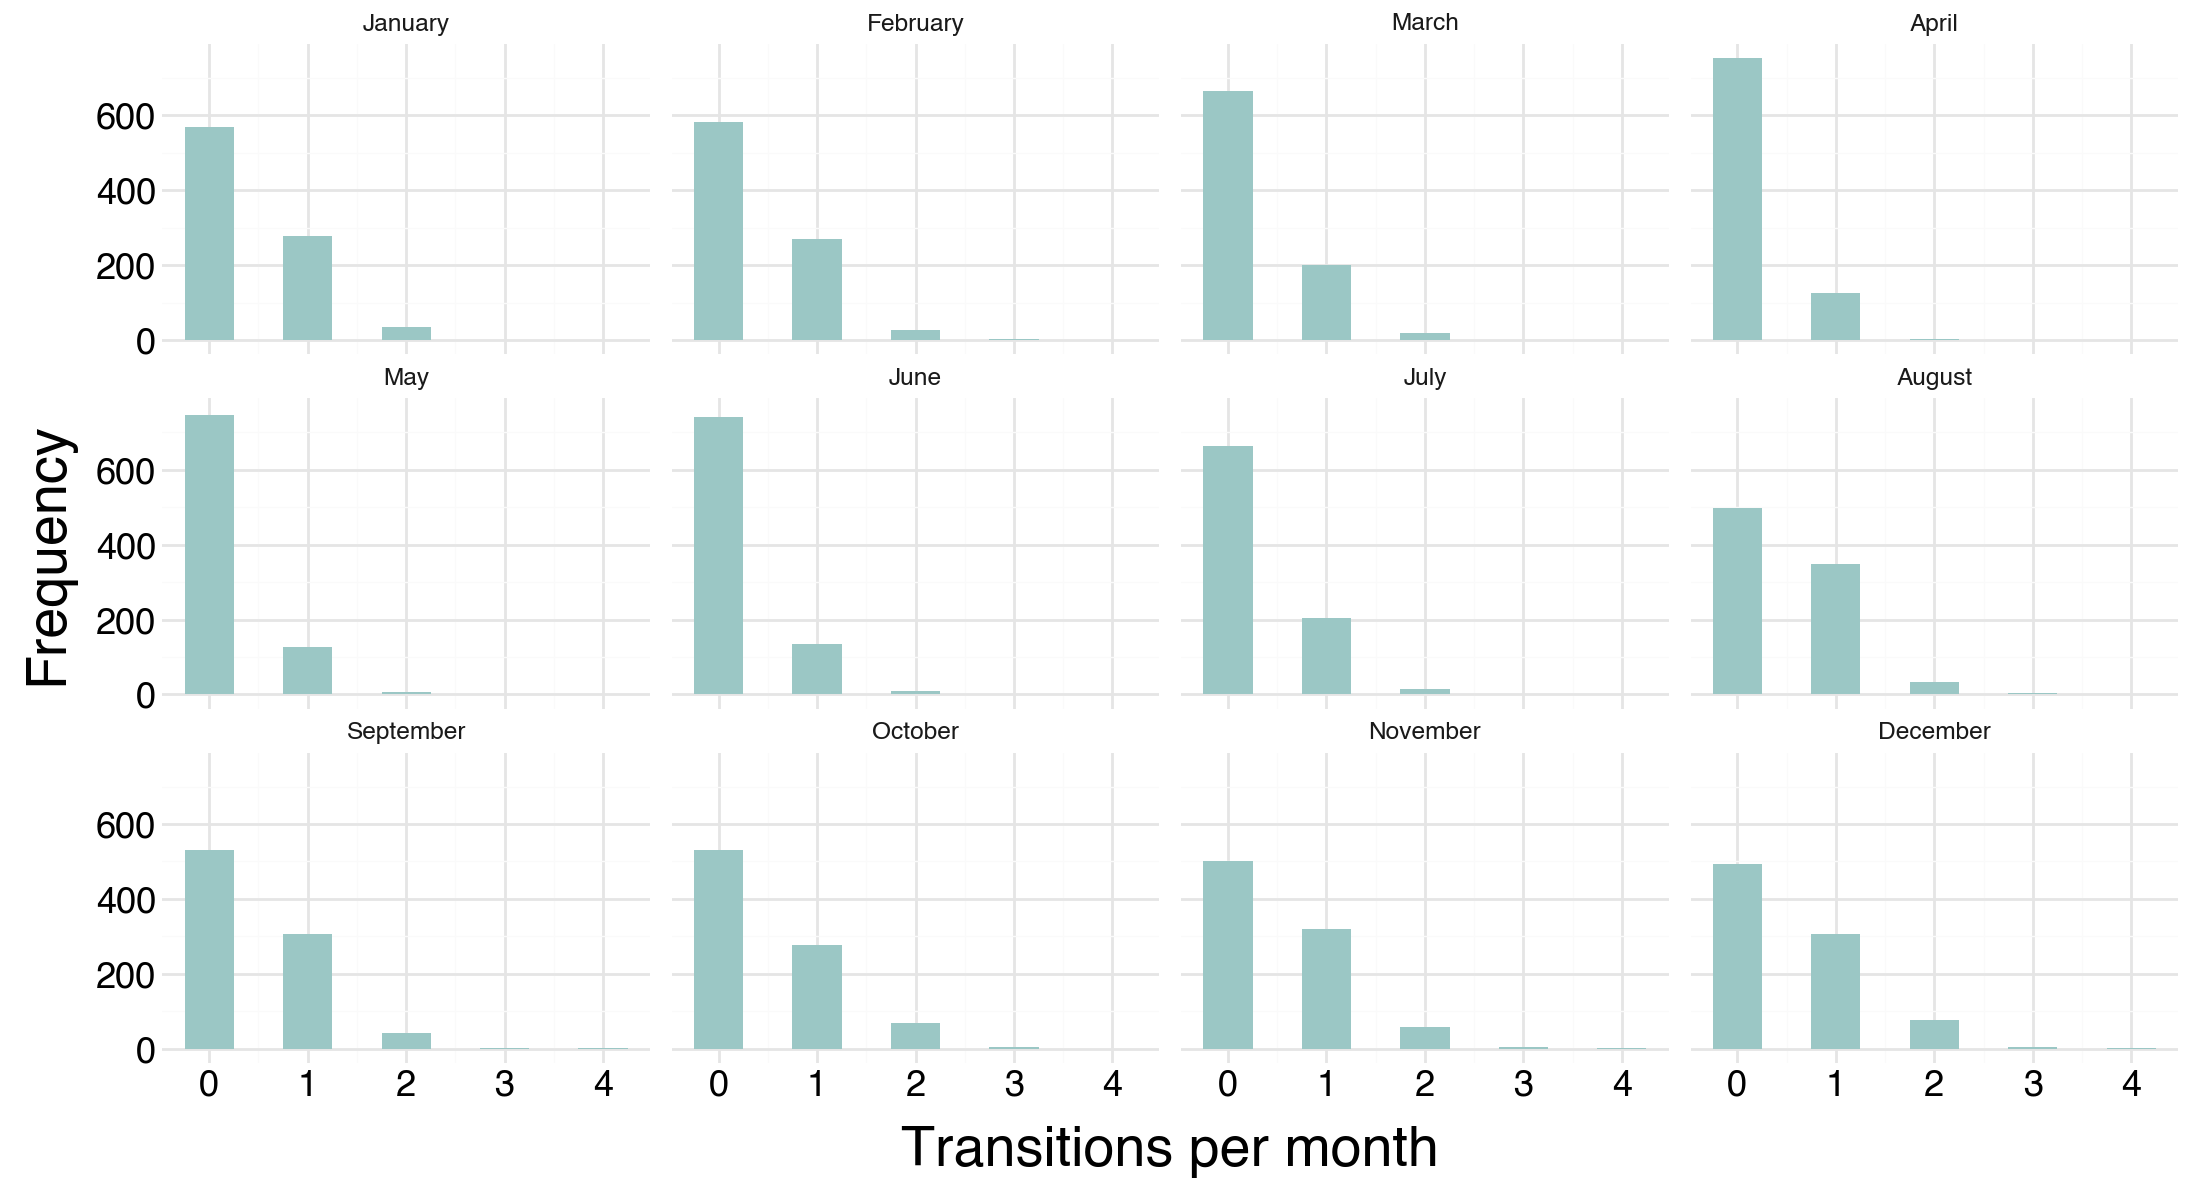

In [30]:
# The Kruskal Wallis test looks very wrong
# Poisson Regression time? 

formula = 'month_trans ~ C(month)'

poisson_EuNAm = smf.glm(formula = formula, data = permonth_EuNAm, family = sm.families.Poisson()).fit()
poisson_NAmEu = smf.glm(formula = formula, data = permonth_NAmEu, family = sm.families.Poisson()).fit()

hist_EuNAm = (
    ggplot(permonth[permonth["combo"] == "europe,northamerica"], aes(x = "month_trans"))
    + geom_histogram(binwidth = 0.5, fill = "#587F0F")
    + labs(x = "Transitions per month", y = "Frequency")
    + facet_wrap("month", labeller = {"january":"January", "february":"February", "march":"March", "april":"April", "may":"May", "june":"June", 
                                      "july":"July", "august":"August", "september":"September", "october":"October", "november":"November", "december":"December"})
    + theme_minimal()
    + theme(figure_size = (11, 6), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), axis_text_y = element_text(size = 13, color = "black"),
            axis_text_x = element_text(size = 13, color = "black"))
)

hist_NAmEu = (
    ggplot(permonth[permonth["combo"] == "northamerica,europe"], aes(x = "month_trans"))
    + geom_histogram(binwidth = 0.5, fill = "#9BC7C5")
    + labs(x = "Transitions per month", y = "Frequency")
    + facet_wrap("month", labeller = {"january":"January", "february":"February", "march":"March", "april":"April", "may":"May", "june":"June", 
                                      "july":"July", "august":"August", "september":"September", "october":"October", "november":"November", "december":"December"})
    + theme_minimal()
    + theme(figure_size = (11, 6), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), axis_text_y = element_text(size = 13, color = "black"),
            axis_text_x = element_text(size = 13, color = "black"))
)


print(poisson_EuNAm.summary())
hist_EuNAm.show()
print(poisson_NAmEu.summary())
hist_NAmEu.show()

In [31]:
hist_EuNAm.save("./SERAPHIM/plots/m-jumps_per-month-dist_EuNAm.png", format = "png", dpi = 750)
hist_NAmEu.save("./SERAPHIM/plots/m-jumps_per-month-dist_NAmEu.png", format = "png", dpi = 750)

/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 11 x 6 in image.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./SERAPHIM/plots/m-jumps_per-month-dist_EuNAm.png
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 11 x 6 in image.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./SERAPHIM/plots/m-jumps_per-month-dist_NAmEu.png


In [215]:
# To plot number of transitions per year
# Chat GPT helped a lot with this, mostly because I just cannot figure out how to bend my brain around this

transition_peryr_rows = []

# get all possible combos in the dataset
all_combos = treejumps["comboContinent"].unique()

for (tree, year), df in treejumps.groupby(["treeNumber", "year"]):
    counts = df["comboContinent"].value_counts()

    # add missing combos with count = 0
    counts = counts.reindex(all_combos, fill_value=0)

    for combo, count in counts.items():
        if combo == "northamerica,northamerica":
            continue
        else:
            # avg_count = 
            transition_peryr_rows.append({"tree":tree, "year": year, "combo": combo, "count": count})
        # print(tree, year, combo, count)

transition_peryr = pd.DataFrame(transition_peryr_rows)

transition_peryr["avg_count"] = transition_peryr.groupby(["tree", "combo"])["count"].transform("mean")

In [216]:
# Chat GPT made this for me after I asked it to fix the following loop

# for combo in transition_peryr_quantiles: 
#     quantiles = transition_peryr.loc["combo" == combo, "avg_count"].quantile([0.025, 0.5, 0.975]).rename({0.025: "lower", 0.5: "median", 0.975: "upper"}) 
#     print(quantiles)

# quantiles = (transition_peryr.groupby("combo")["avg_count"].quantile([0.025, 0.5, 0.975])
#              .unstack().rename(columns={0.025: "lower", 0.5: "median", 0.975: "upper"}))

# The above computes quantiles... I technically want 95% HPD intervals
trans_peryr_hpd = transition_peryr.groupby("combo")["avg_count"].apply(lambda col: az.hdi(col.values, hdi_prob = 0.95)).apply(pd.Series)
trans_peryr_hpd.columns = ["lower", "upper"]
trans_peryr_hpd["median"] = transition_peryr.groupby("combo")["avg_count"].median()
trans_peryr_hpd = trans_peryr_hpd.reset_index()

trans_peryr_hpd["labels"] = trans_peryr_hpd["combo"].str.split(",",expand = True)[0].map(labels_dict) + " - " + trans_peryr_hpd["combo"].str.split(",",expand = True)[1].map(labels_dict)

In [217]:
print(trans_peryr_hpd)

                 combo  lower  upper  median                  labels
0          asia,europe    0.0   0.00    0.00           Asia - Europe
1    asia,northamerica    0.0   0.00    0.00    Asia - North America
2          europe,asia    0.4   0.50    0.50           Europe - Asia
3  europe,northamerica    1.6   2.75    2.25  Europe - North America
4    northamerica,asia    0.0   0.00    0.00    North America - Asia
5  northamerica,europe    0.8   1.25    1.00  North America - Europe


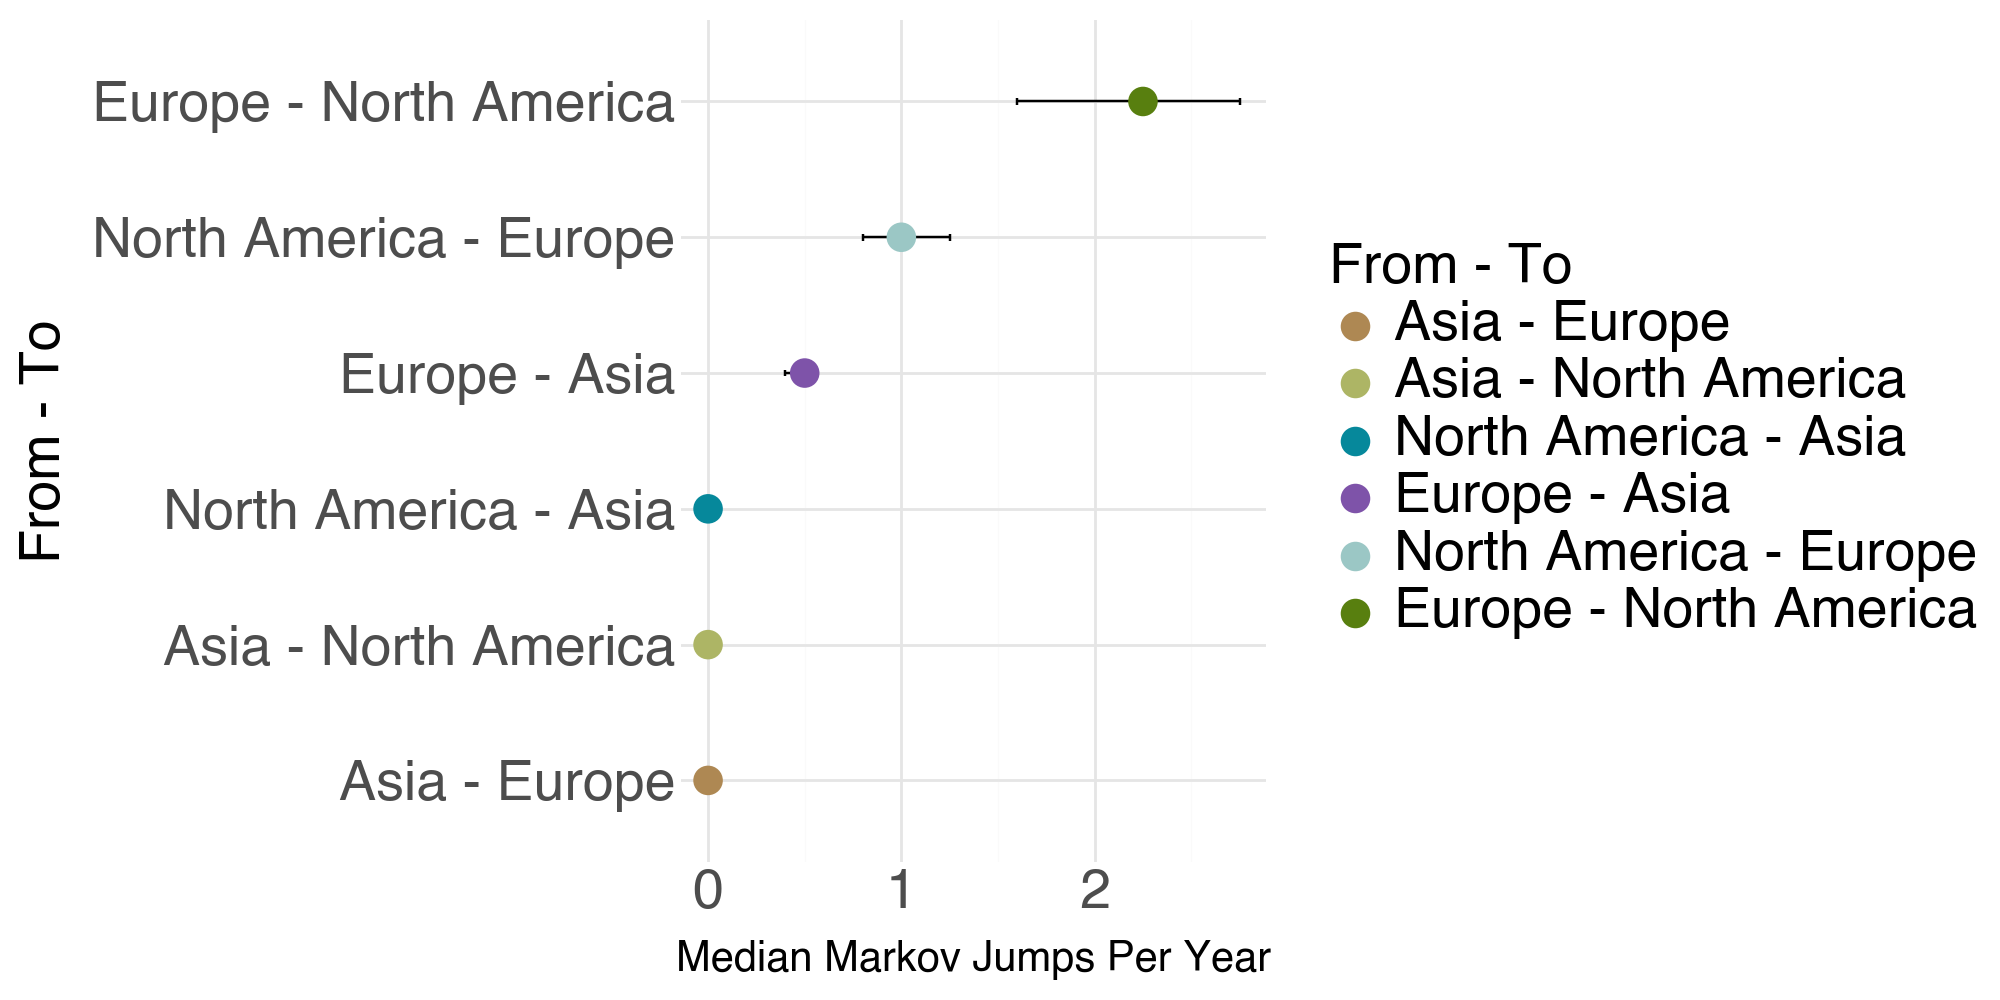

In [244]:
level = ["Asia - Europe", "Asia - North America", "North America - Asia", 
         "Europe - Asia", "North America - Europe", "Europe - North America"] 

# Put labels in order of largest to smallest (upper)
trans_peryr_hpd["labels"] = pd.Categorical(trans_peryr_hpd["labels"], categories=level, ordered=True)


plt5 = (
    ggplot(trans_peryr_hpd, aes(x = "labels", y = "median", color = "labels"))
    + geom_errorbar(aes(ymin = "lower", ymax = "upper"), width = 0.05, color = "black")
    + geom_point(stat = "identity", size = 5)
    + scale_color_manual(colors)
    + labs(x = "From - To", y = "Median Markov Jumps Per Year", color = "From - To")
    + coord_flip()
    + theme_minimal()
    + theme(figure_size = (10, 5), axis_title_x = element_text(size = 15), axis_title_y = element_text(size = 20), text=element_text(size=20)) # axis_text_x=element_text(rotation=60)
)

plt5.show()

In [245]:
# plt5.save("./SERAPHIM/output_plots/mj_med-per-year.png", format = "png", dpi = 750)
plt5.save("./SERAPHIM/plots/m-jumps_median-per-yr_continents.png", format = "png", dpi = 750)

/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 5 in image.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./SERAPHIM/plots/m-jumps_median-per-yr_continents.png


In [246]:
# Bayes factor for transitions

# read in Bayes analysis from spread
# bayes = pd.read_csv("./BEAST/cont-phyl_dta/results/2026-03-10_A6_concat_genome_traits_greenland-europe/region_bayes.txt.txt", sep = "\t")
# bayes = pd.read_csv("./BEAST/cont-phyl_dta/results/2026-07-09_A6_concat_genome_traits/region_bayes.txt.txt", sep = "\t")
bayes = pd.read_csv("./BEAST/cont-phyl_dta/results/2026-08-04_A6_concat_genome_traits_TEST/region_bayes.txt.txt", sep = "\t")

# read in rates combined log file
# rates_combined = pd.read_csv("./BEAST/cont-phyl_dta/results/2026-03-10_A6_concat_genome_traits_greenland-europe/A6_concat-genome_traits_gnl-eu_202603-10_combined.region.rates.log",sep = "\t").T
# rates_combined.loc[rates_combined.index.astype(str).str.contains("indicators"), "mean_post_prob"] = rates_combined.mean(axis = 1) # mean indicators matches posterior probability
# indicators_combined = rates_combined.loc[rates_combined.index.astype(str).str.contains("indicators")].reset_index()

# I was not able to figure out how to compute the correct mean from the combined log file
# So I assigned location labels by hand
bayes["FROM_CONTINENT"] = bayes["FROM_LABEL"].map(continent_dict)
bayes["TO_CONTINENT"] = bayes["TO_LABEL"].map(continent_dict)
bayes["labels"] = bayes["FROM_CONTINENT"].map(labels_dict) + " - " + bayes["TO_CONTINENT"].map(labels_dict)

# Remove within-north-america transitions (because we're not interested in them here)
bayes_cross_continent = bayes[~(bayes["labels"] == "North America - North America")]

# Also, there are no asia-to-europe transitions in this dataset
# The Bayes Factor is really low, so I'm going to remove it
# bayes_cross_continent_filtered = bayes_cross_continent[~(bayes_cross_continent["labels"] == "Asia - Europe")]

# print(bayes_cross_continent)

/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10


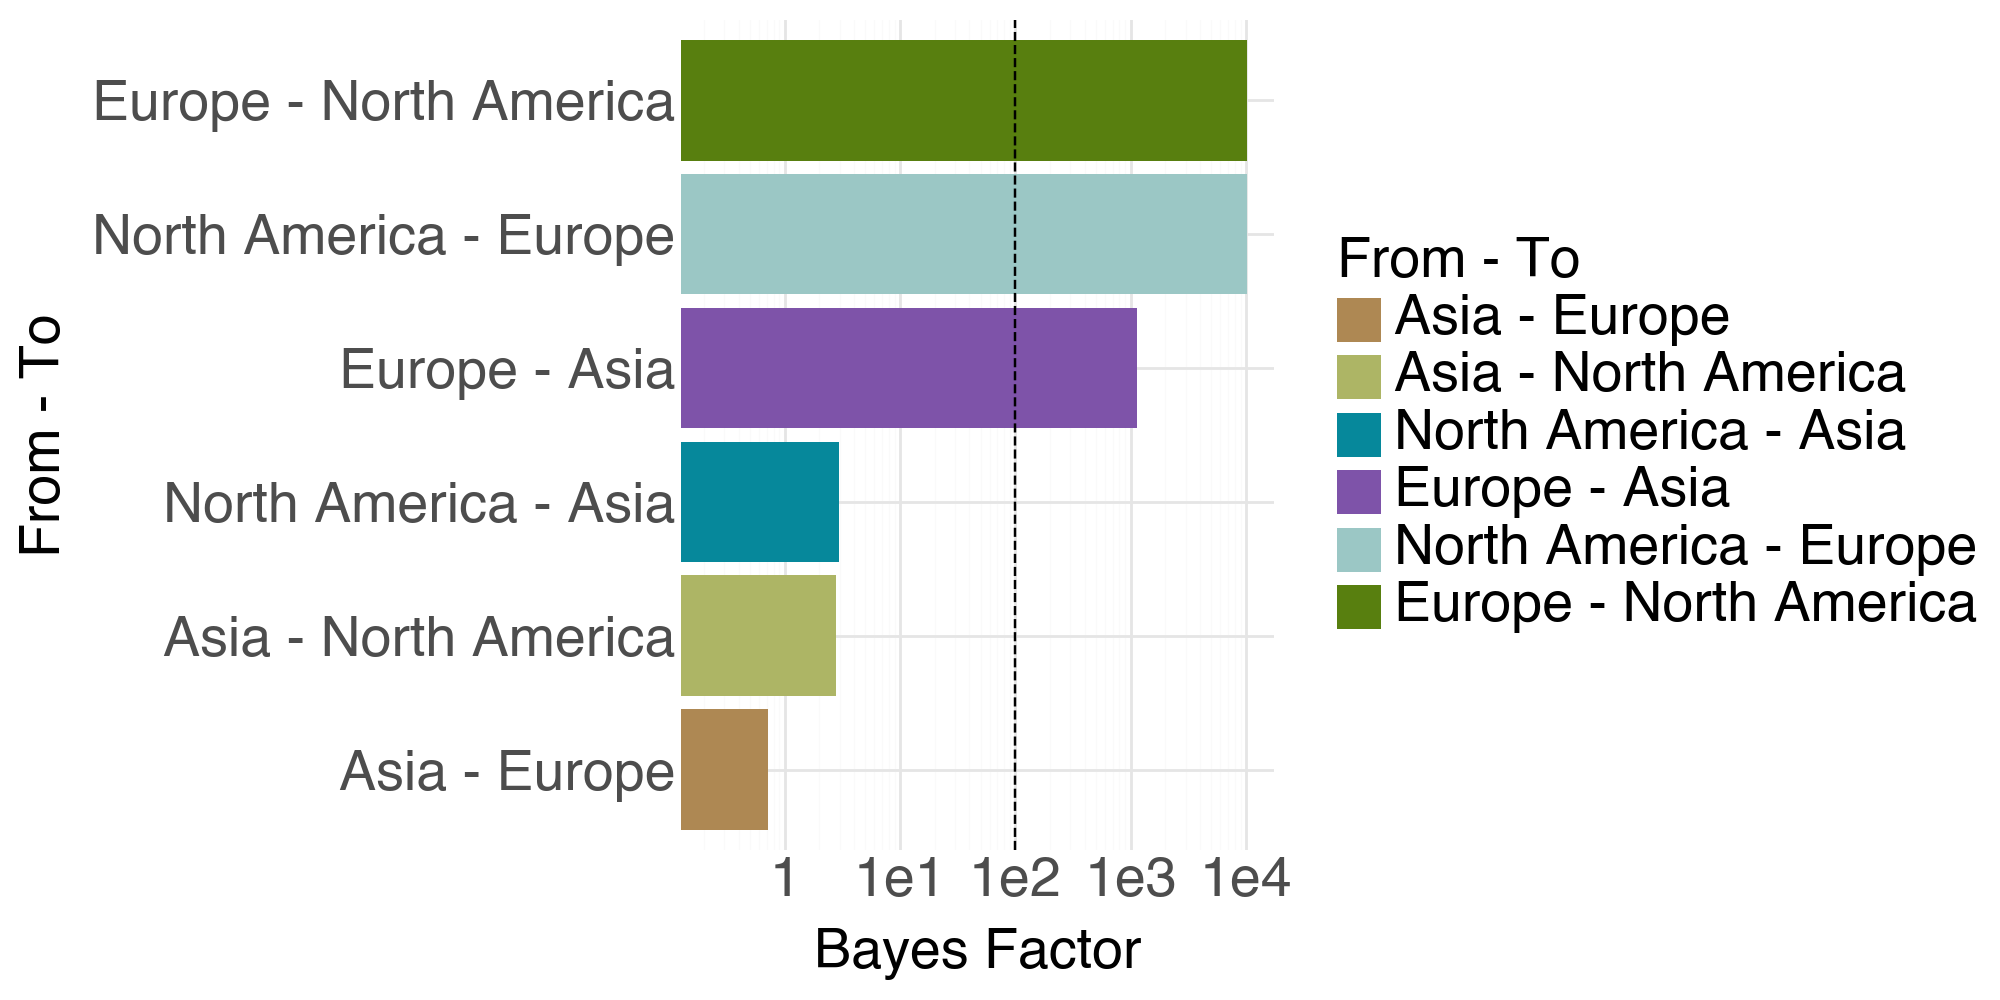

In [247]:
level = ["Asia - Europe", "Asia - North America", "North America - Asia", 
         "Europe - Asia", "North America - Europe", "Europe - North America"
        ]

# Put labels in order of largest to smallest (upper)
bayes_cross_continent["labels"] = pd.Categorical(bayes_cross_continent["labels"], categories=level, ordered=True)


plt6 = (
    ggplot(bayes_cross_continent, aes(x = "labels", y = "BAYES_FACTOR", fill = "labels"))
    + geom_col(stat = "identity")
    + scale_fill_manual(colors)
    + labs(x = "From - To", y = "Bayes Factor", fill = "From - To")
    + coord_flip()
    + scale_y_log10()
    + geom_hline(yintercept = 1e2, linetype = "dashed")
    + theme_minimal()
    + theme(figure_size = (10, 5), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), text=element_text(size=20)) # axis_text_x=element_text(rotation=60)
)

plt6.show()

In [248]:
# plt6.save("./SERAPHIM/output_plots/bayes_factor_region.png", format = "png", dpi = 750)
plt6.save("./SERAPHIM/plots/bayes-factors_continents.png", format = "png", dpi = 750)

/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 5 in image.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./SERAPHIM/plots/bayes-factors_continents.png
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10


In [249]:
# How might I calculate Markov rewards?

In [250]:
# Function: the first function reads in a tree, and the second one extracts height and rewards from each node of the tree

def load_tree(nexusPath):
    mytree = bt.loadNexus(nexusPath, tip_regex='\|([0-9]{4}\-[0-9]{2}\-[0-9]{2})', absoluteTime=True, verbose=False) # your tip regex might have to change or you could convert you tree into a newick by deleting everything before the tree string lol
    return(mytree)

def rewards_metadata(treePath, MRSD):

    tree = load_tree(treePath) # load tree
    
    metadata = []
    
    for k in tree.Objects:
        if k.traits != None: # don't worry about the root
            metadict = {
                'branchType': k.branchType,  # 'leaf' or 'node'
                'height': k.traits.get("height"), # extract node or leaf height for date
                'asia_r': k.traits.get("asia_reward"), # extract rewards from each node and leaf
                'north_canada_r': k.traits.get("northcanada_reward"),
                'east_canada_r': k.traits.get("eastcanada_reward"),
                'europe_r': k.traits.get("europe_reward"),
                'northeast_us_r': k.traits.get("northeastus_reward"),
                'northwest_us_r': k.traits.get("northwestus_reward"),
                        }
            metadata.append(metadict)
            
        metadata_df = pd.DataFrame(metadata)

        metadata_df["date"] = MRSD - metadata_df["height"] # assign date using most recent sampling date and height
    
    return(metadata_df)

# rewards = rewards_metadata("./BEAST/cont-phyl_dta/results/2026-07-09_A6_concat_genome_traits/A6_concat-gen_traits_2026-07-09_MCC_edited.region.history.tree", 2026.0520547945205)
rewards = rewards_metadata("./BEAST/cont-phyl_dta/results/2026-08-04_A6_concat_genome_traits_TEST/A6_concat-gen_traits_2026-08-04_MCC_edited.region.history.tree", 2026.0520547945205)

In [222]:
# Manipulate the rewards dataframe (ChatGPT helped me understand the steps Lambo followed in his script, and I followed that)

# Sum rewards by year so you have the number of each region per time
# Compute the sum and proportions
rewards_prop = rewards.copy()
rewards_prop["total"] = rewards_prop["asia_r"]+rewards_prop["east_canada_r"]+rewards_prop["europe_r"]+rewards_prop["north_canada_r"]+rewards_prop["northeast_us_r"]+rewards_prop["northwest_us_r"]
rewards_prop["asia_p"] = rewards_prop["asia_r"] / rewards_prop["total"]
rewards_prop["east-canada_p"] = rewards_prop["east_canada_r"] / rewards_prop["total"]
rewards_prop["europe_p"] = rewards_prop["europe_r"] / rewards_prop["total"]
rewards_prop["north-canada_p"] = rewards_prop["north_canada_r"] / rewards_prop["total"]
rewards_prop["northeast-us_p"] = rewards_prop["northeast_us_r"] / rewards_prop["total"]
rewards_prop["northwest-us_p"] = rewards_prop["northwest_us_r"] / rewards_prop["total"]

# We know that the origin point is total in Europe, so I can set the proportion in Europe at node 0 to 1.0
rewards_prop.loc[rewards_prop.index == 0, "europe_p"] = 1.0
rewards_prop.loc[rewards_prop.index == 0, "asia_p"] = 0.0
rewards_prop.loc[rewards_prop.index == 0, "east-canada_p"] = 0.0
rewards_prop.loc[rewards_prop.index == 0, "north-canada_p"] = 0.0
rewards_prop.loc[rewards_prop.index == 0, "northeast-us_p"] = 0.0
rewards_prop.loc[rewards_prop.index == 0, "northwest-us_p"] = 0.0

# Keep only proportions and year
prop_columns = ["branchType", "height", "date", "asia_p", "europe_p", "east-canada_p", "north-canada_p", "northeast-us_p", "northwest-us_p"]
rewards_prop_final = rewards_prop[prop_columns]

# Convert back to long format?

# Define one-week intervals
interval_width = 1 / 52.14 # 52.14 weeks in a year
weekly_sequence = np.arange(rewards_prop_final["date"].min(), rewards_prop_final["date"].max() + interval_width, interval_width)

# Assign each observation to a week interval
rewards_prop_final["week"] = pd.cut(rewards_prop_final["date"], weekly_sequence, right = True, labels = weekly_sequence[:-1], include_lowest = True) 
# ChatGPT helped point me to the above command
# I understand most of what it is doing from the documentation, but I don't really get the labels argument... that is just what ChatGPT suggested...

# Average the proportions of each state within each week
wk_dict = {}

for i in rewards_prop_final.columns:
    if "_p" in i:
        state = i.split("_")[0]
        wk_dict[f"{state}"] = rewards_prop_final.groupby("week")[i].mean()

weekly_rewards = pd.DataFrame(wk_dict).reset_index()

# Extract the upper limit of each interval > not sure why tho

weekly_rewards_melted = pd.melt(weekly_rewards, id_vars = "week", var_name = "location", value_name = "value")
weekly_rewards_melted["week"] = pd.to_numeric(weekly_rewards_melted["week"])
print(weekly_rewards_melted)

             week      location     value
0     2020.470779          asia  0.000000
1     2021.218765          asia  0.000310
2     2021.314661          asia  0.000000
3     2021.506452          asia  0.000000
4     2021.621527          asia  0.000000
...           ...           ...       ...
1051  2025.725861  northwest-us  0.000000
1052  2025.840936  northwest-us  0.995151
1053  2025.860115  northwest-us  0.497868
1054  2026.013548  northwest-us  0.000000
1055  2026.051907  northwest-us  0.000000

[1056 rows x 3 columns]


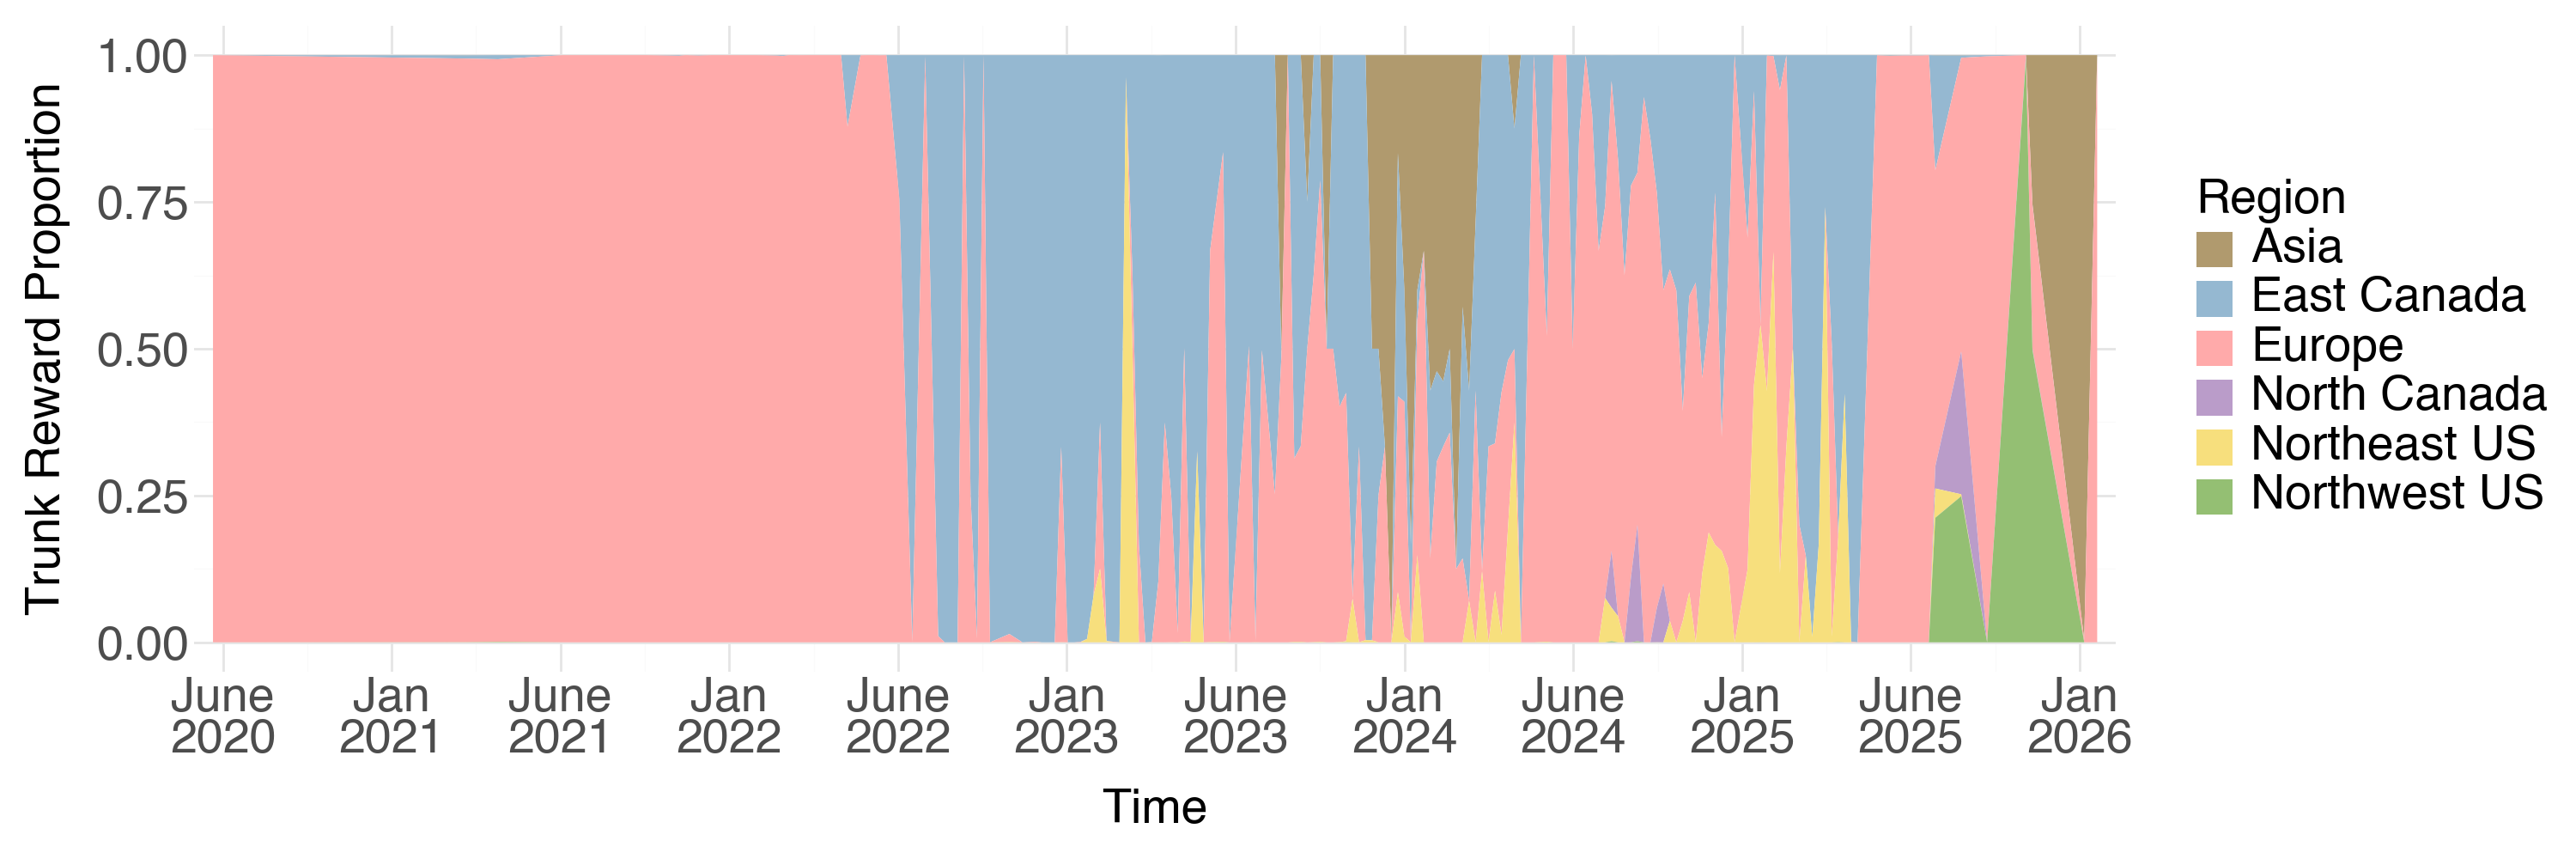

In [223]:
plt7_alt1 = (
    ggplot(weekly_rewards_melted, aes(x = "week", y = "value", fill = "location", group = "location"))
    + geom_area()
    + scale_x_continuous(breaks = [2020.5, 2021, 2021.5, 2022, 2022.5, 2023, 2023.5, 2024, 2024.5, 2025, 2025.5, 2026],
                         # limits = [2020, 2026.25],
                         expand= [0.01, 0],
                         labels = ["June\n2020", "Jan\n2021", "June\n2021", "Jan\n2022", "June\n2022", "Jan\n2023", "June\n2023", "Jan\n2024", "June\n2024", "Jan\n2025", "June\n2025", "Jan\n2026"]
                        )
    + scale_fill_manual(values = {"europe":"#ffaaaa", "east-canada":"#95b8d1", "northeast-us":"#f7df7d", "north-canada":"#ba9cc9", "northwest-us":"#94bf73", "asia":"#b09a6e"}, 
                       labels = {"europe":"Europe", "east-canada":"East Canada", "northeast-us":"Northeast US", "north-canada":"North Canada", "northwest-us":"Northwest US", "asia":"Asia"})
    + labs(x = "Time", y = "Trunk Reward Proportion", fill = "Region")
    + theme_minimal()
    + theme(figure_size = (15, 5), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), text=element_text(size=20))
)

plt7_alt1.show()

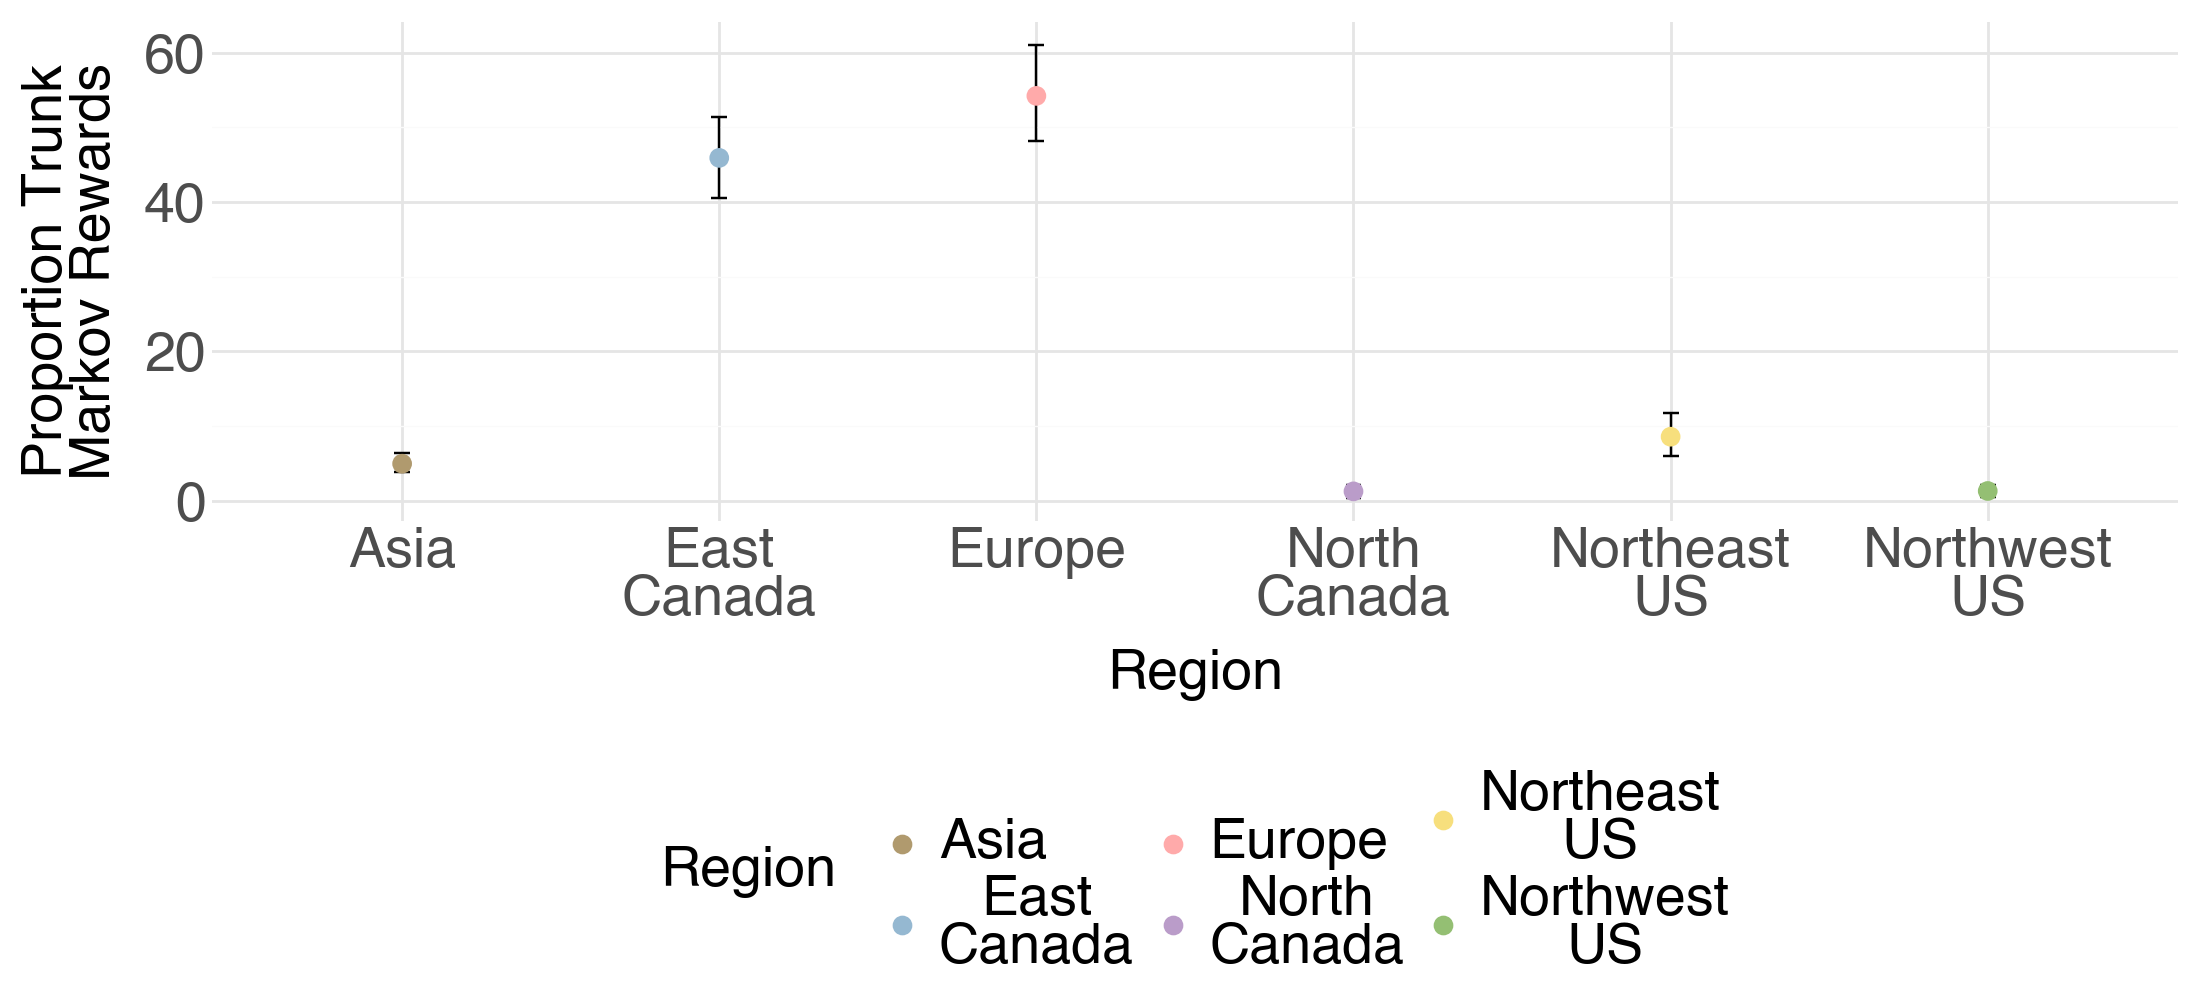

In [225]:
# Read in the combined log file, dig out the Markov rewards, and plot as a bar chart

# log = pd.read_csv("./BEAST/cont-phyl_dta/results/2026-07-09_A6_concat_genome_traits/A6_concat-gen_traits_2026-07-09_combined.log", sep = "\t")
log = pd.read_csv("./BEAST/cont-phyl_dta/results/2026-08-04_A6_concat_genome_traits_TEST/A6_concat-gen_traits_2026-08-04_combined.log", sep = "\t")

# rewards_columns = log.columns[log.columns.str.contains("_reward")]
rewards_columns = ["c_asia_reward[1]", "c_east-canada_reward[1]", "c_europe_reward[1]", "c_north-canada_reward[1]", "c_northeast-us_reward[1]", "c_northwest-us_reward[1]"]
log_rewards = log[rewards_columns]

# Compute median and HPD
log_rewards_hpd = log_rewards.apply(lambda col: az.hdi(col.values, hdi_prob=0.95)).T
log_rewards_hpd.columns = ["lower", "upper"]
log_rewards_hpd["median"] = log_rewards.median()

log_rewards_hpd["labels"] = ["Asia", "East\nCanada", "Europe", "North\nCanada", "Northeast\nUS", "Northwest\nUS"]

plt7_alt2 = (
    ggplot(log_rewards_hpd, aes(x = "labels", y = "median", fill = "labels", color = "labels"))
    + geom_errorbar(aes(ymin = "lower", ymax = "upper"), width = 0.05, color = "black")
    + geom_point(size = 3)
    + labs(x = "Region", y = "Proportion Trunk\nMarkov Rewards", fill = "Region", color = "Region")
    + scale_fill_manual({"Europe":"#ffaaaa", "East\nCanada":"#95b8d1", "Northeast\nUS":"#f7df7d", "North\nCanada":"#ba9cc9", "Northwest\nUS":"#94bf73", "Asia":"#b09a6e"})
    + scale_color_manual({"Europe":"#ffaaaa", "East\nCanada":"#95b8d1", "Northeast\nUS":"#f7df7d", "North\nCanada":"#ba9cc9", "Northwest\nUS":"#94bf73", "Asia":"#b09a6e"})
    + theme_minimal()
    + theme(figure_size = (11, 5), axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), 
            text=element_text(size=20), legend_position = "bottom", legend_direction = "horizontal"))

plt7_alt2.show()

In [226]:
plt7_alt1.save("./SERAPHIM/plots/m-rewards_weekly-prop_region.png", format = "png", dpi = 750)
plt7_alt2.save("./SERAPHIM/plots/m-rewards_total-prop_region.png", format = "png", dpi = 750)

/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 15 x 5 in image.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./SERAPHIM/plots/m-rewards_weekly-prop_region.png
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 11 x 5 in image.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./SERAPHIM/plots/m-rewards_total-prop_region.png
